# PVC-6 Supplementary Final Figures

Clean figure-generation notebook. Loads all results from pickle — no recomputation. Run top-to-bottom to reproduce all supplementary figures.

In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/pvc-6/pvc6_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/shared_helper_modules/')
from pvc6_plotting import *
from pvc6_stim_analysis import *
from spikewise_plotting import plot_corr_heatmap_only_spk

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_style('white')
import warnings
warnings.filterwarnings('ignore')
set_plot_style()

PICKLE_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/'
WINDOWS_MS = [5, 25, 50, 100, 200, 300, 400, 500]

def _load(path):
    with open(path, 'rb') as fh:
        return pickle.load(fh)

## Load Pickles

In [2]:
# ── Cell 1 ────────────────────────────────────────────────────────────────────
df_stim_features_c1, _ = (
    _load(os.path.join(PICKLE_DIR, 'df_stim_features.pkl')),
    _load(os.path.join(PICKLE_DIR, 'all_data.pkl')),
)
logr_accs_c1      = _load(os.path.join(PICKLE_DIR, 'logr_accs.pkl'))
svm_accs_c1       = _load(os.path.join(PICKLE_DIR, 'svm_accs.pkl'))
rf_accs_c1        = _load(os.path.join(PICKLE_DIR, 'rf_accs.pkl'))
rf_model_c1       = _load(os.path.join(PICKLE_DIR, 'rf_model.pkl'))
rf_imps_c1        = _load(os.path.join(PICKLE_DIR, 'rf_importances.pkl'))
results_win_c1    = _load(os.path.join(PICKLE_DIR, 'results_window.pkl'))
df_pink_filt_c1   = _load(os.path.join(PICKLE_DIR, 'df_pink_filtered_c1.pkl'))
df_all_c1         = _load(os.path.join(PICKLE_DIR, 'df_all_c1.pkl'))
print('Cell 1 pickles loaded.')

Cell 1 pickles loaded.


In [3]:
# ── Cell 2 ────────────────────────────────────────────────────────────────────
df_stim_features_c2, _ = (
    _load(os.path.join(PICKLE_DIR, 'df_stim_features2.pkl')),
    _load(os.path.join(PICKLE_DIR, 'all_data2.pkl')),
)
logr_accs_c2_bin  = _load(os.path.join(PICKLE_DIR, 'logr_accs2_binary.pkl'))
svm_accs_c2_bin   = _load(os.path.join(PICKLE_DIR, 'svm_accs2_binary.pkl'))
rf_accs_c2_bin    = _load(os.path.join(PICKLE_DIR, 'rf_accs2_binary.pkl'))
rf_model_c2       = _load(os.path.join(PICKLE_DIR, 'rf_model2.pkl'))
rf_imps_c2        = _load(os.path.join(PICKLE_DIR, 'rf_importances2.pkl'))
results_win_c2    = _load(os.path.join(PICKLE_DIR, 'results_window2.pkl'))
df_pink_filt_c2   = _load(os.path.join(PICKLE_DIR, 'df_pink_filtered_c2.pkl'))
df_all_c2         = _load(os.path.join(PICKLE_DIR, 'df_all_c2.pkl'))
print('Cell 2 pickles loaded.')

Cell 2 pickles loaded.


## Fig S1 — Intra-Spike Feature Correlation Matrix

Lower-triangle Pearson correlation heatmap across all spike waveform features (pink noise spikes only).

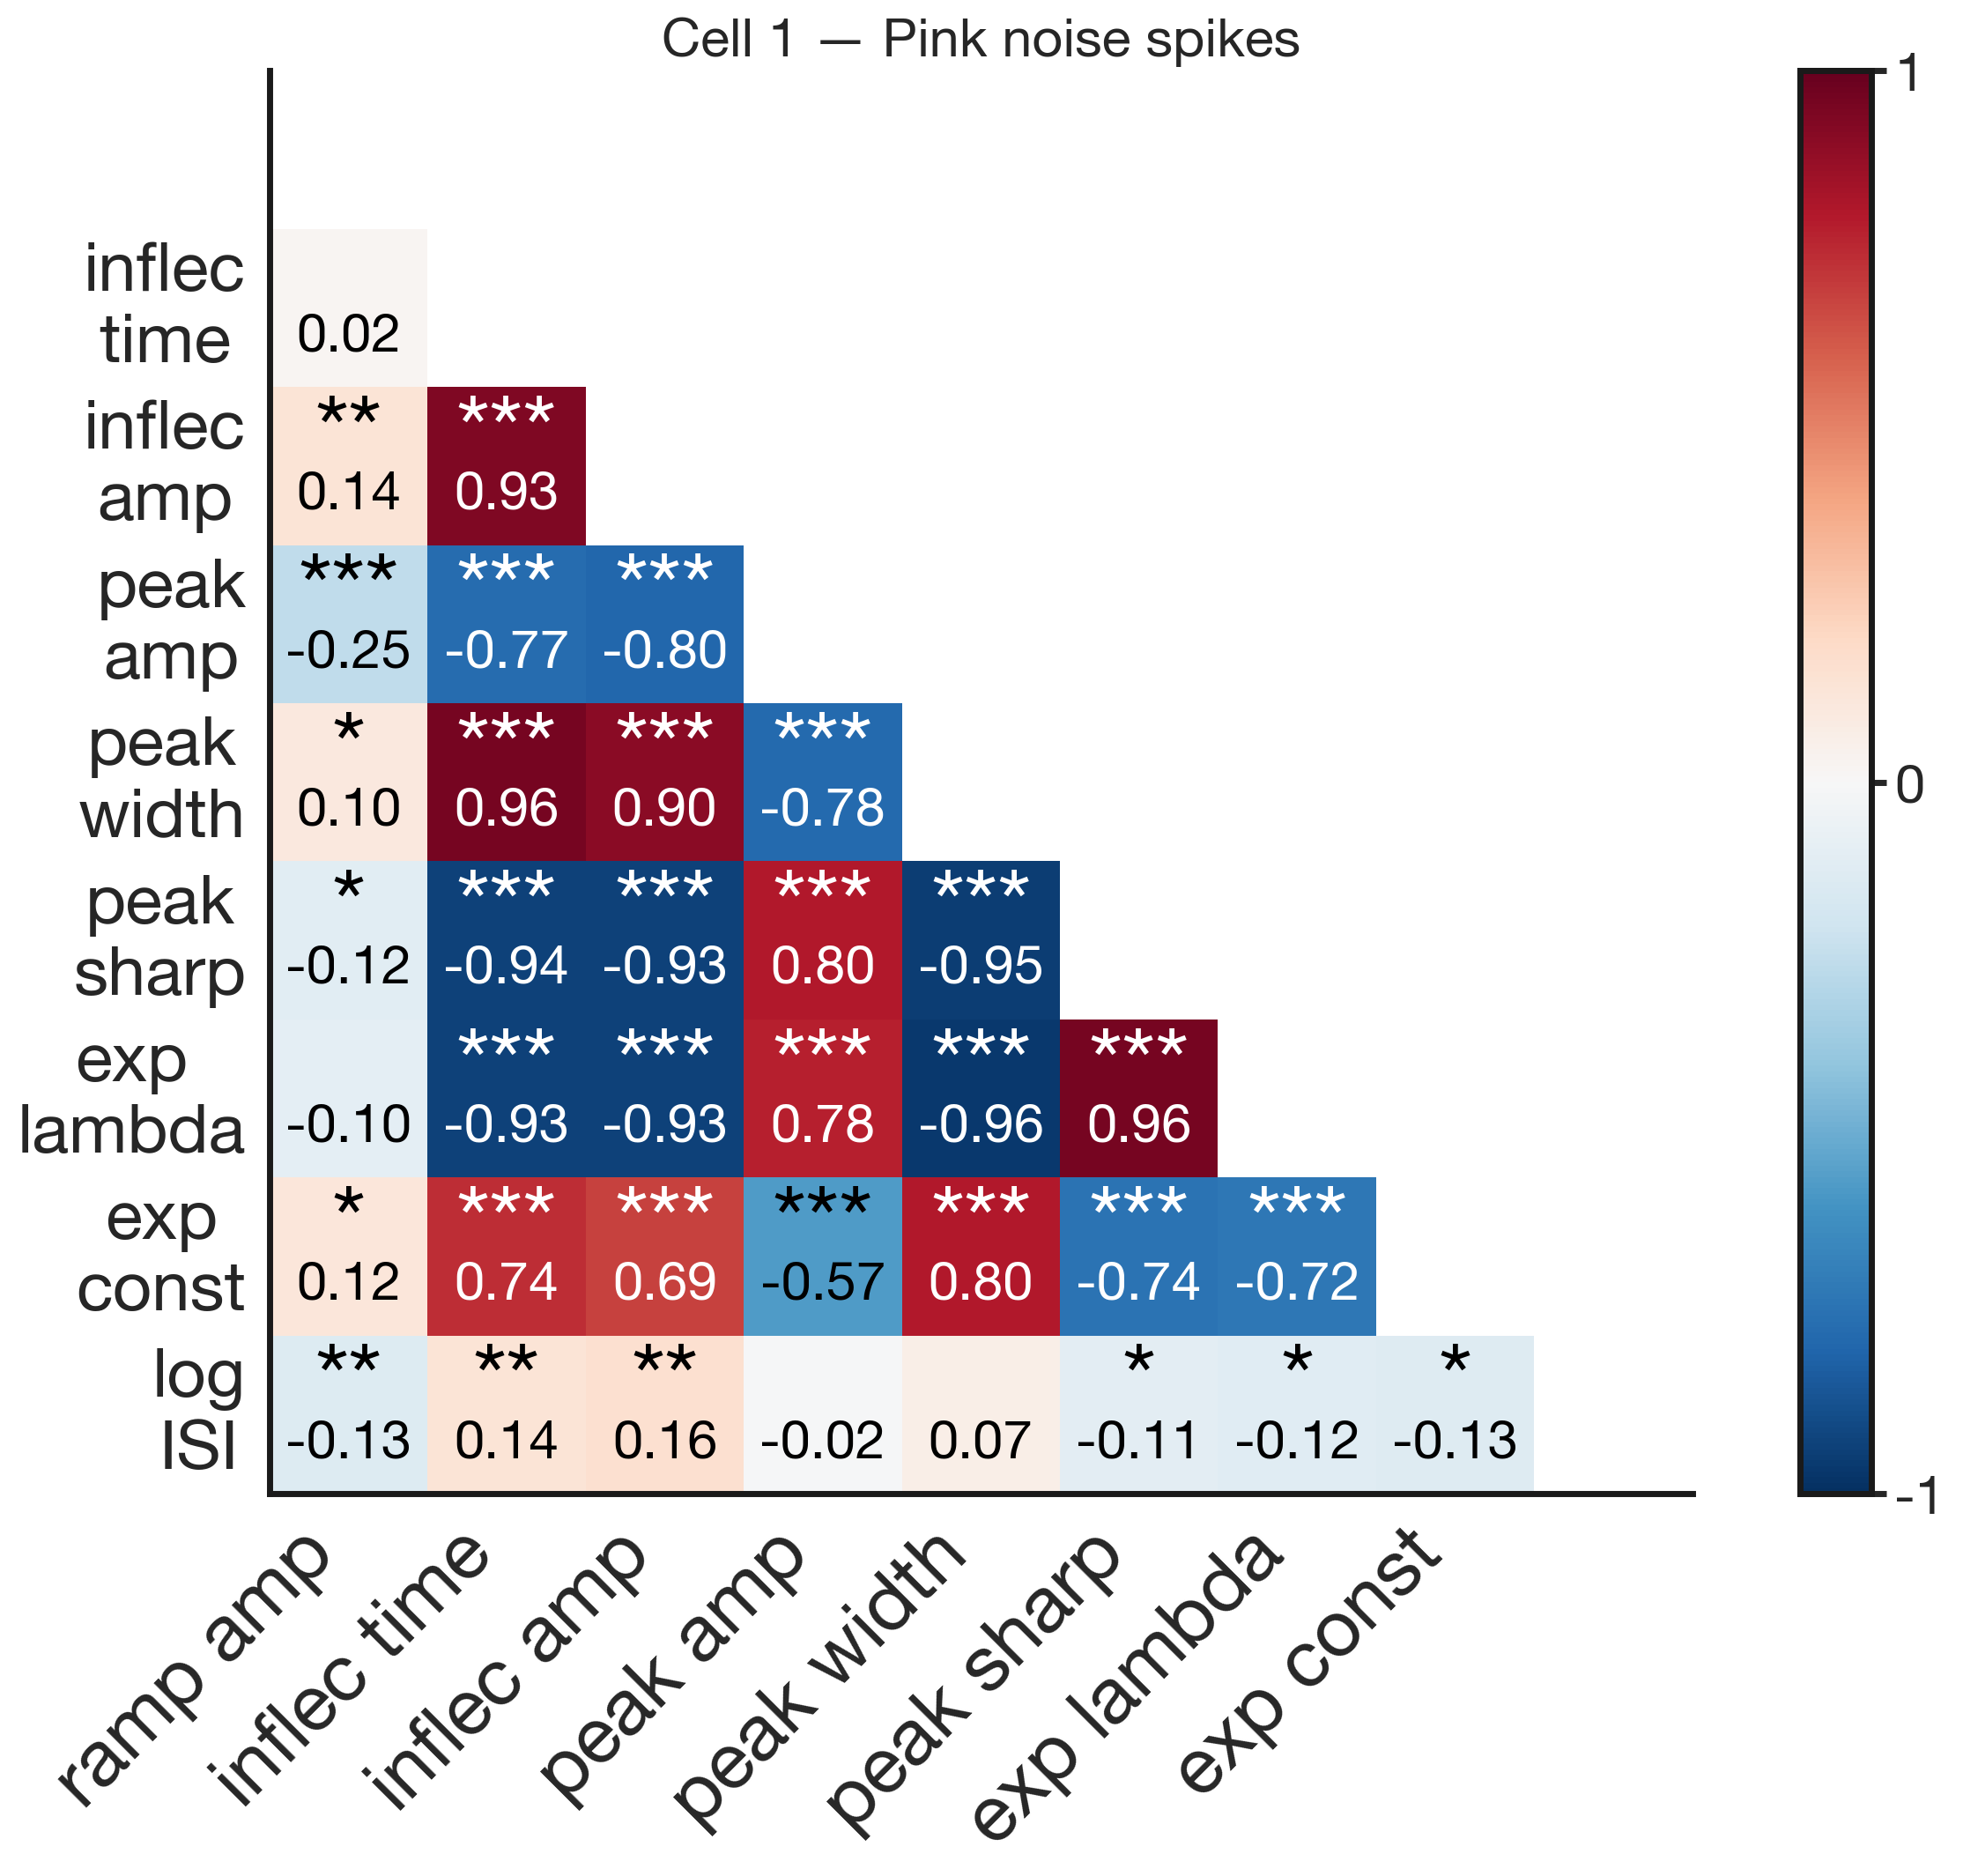

In [4]:
# Cell 1 — pink spikes only (pre-filtered, all spike features incl. log ISI)
_drop = ['sweep', 'stim_type', 'pink_type', 'spike_num']
df_pink_c1 = df_pink_filt_c1.drop(_drop, axis=1, errors='ignore')
spike_features_c1 = [c for c in df_pink_c1.columns
                     if c not in ('stim_exp', 'stim_mean', 'stim_std')]
plot_corr_heatmap_only_spk(df_pink_c1, spike_features_c1, title='Cell 1 — Pink noise spikes')

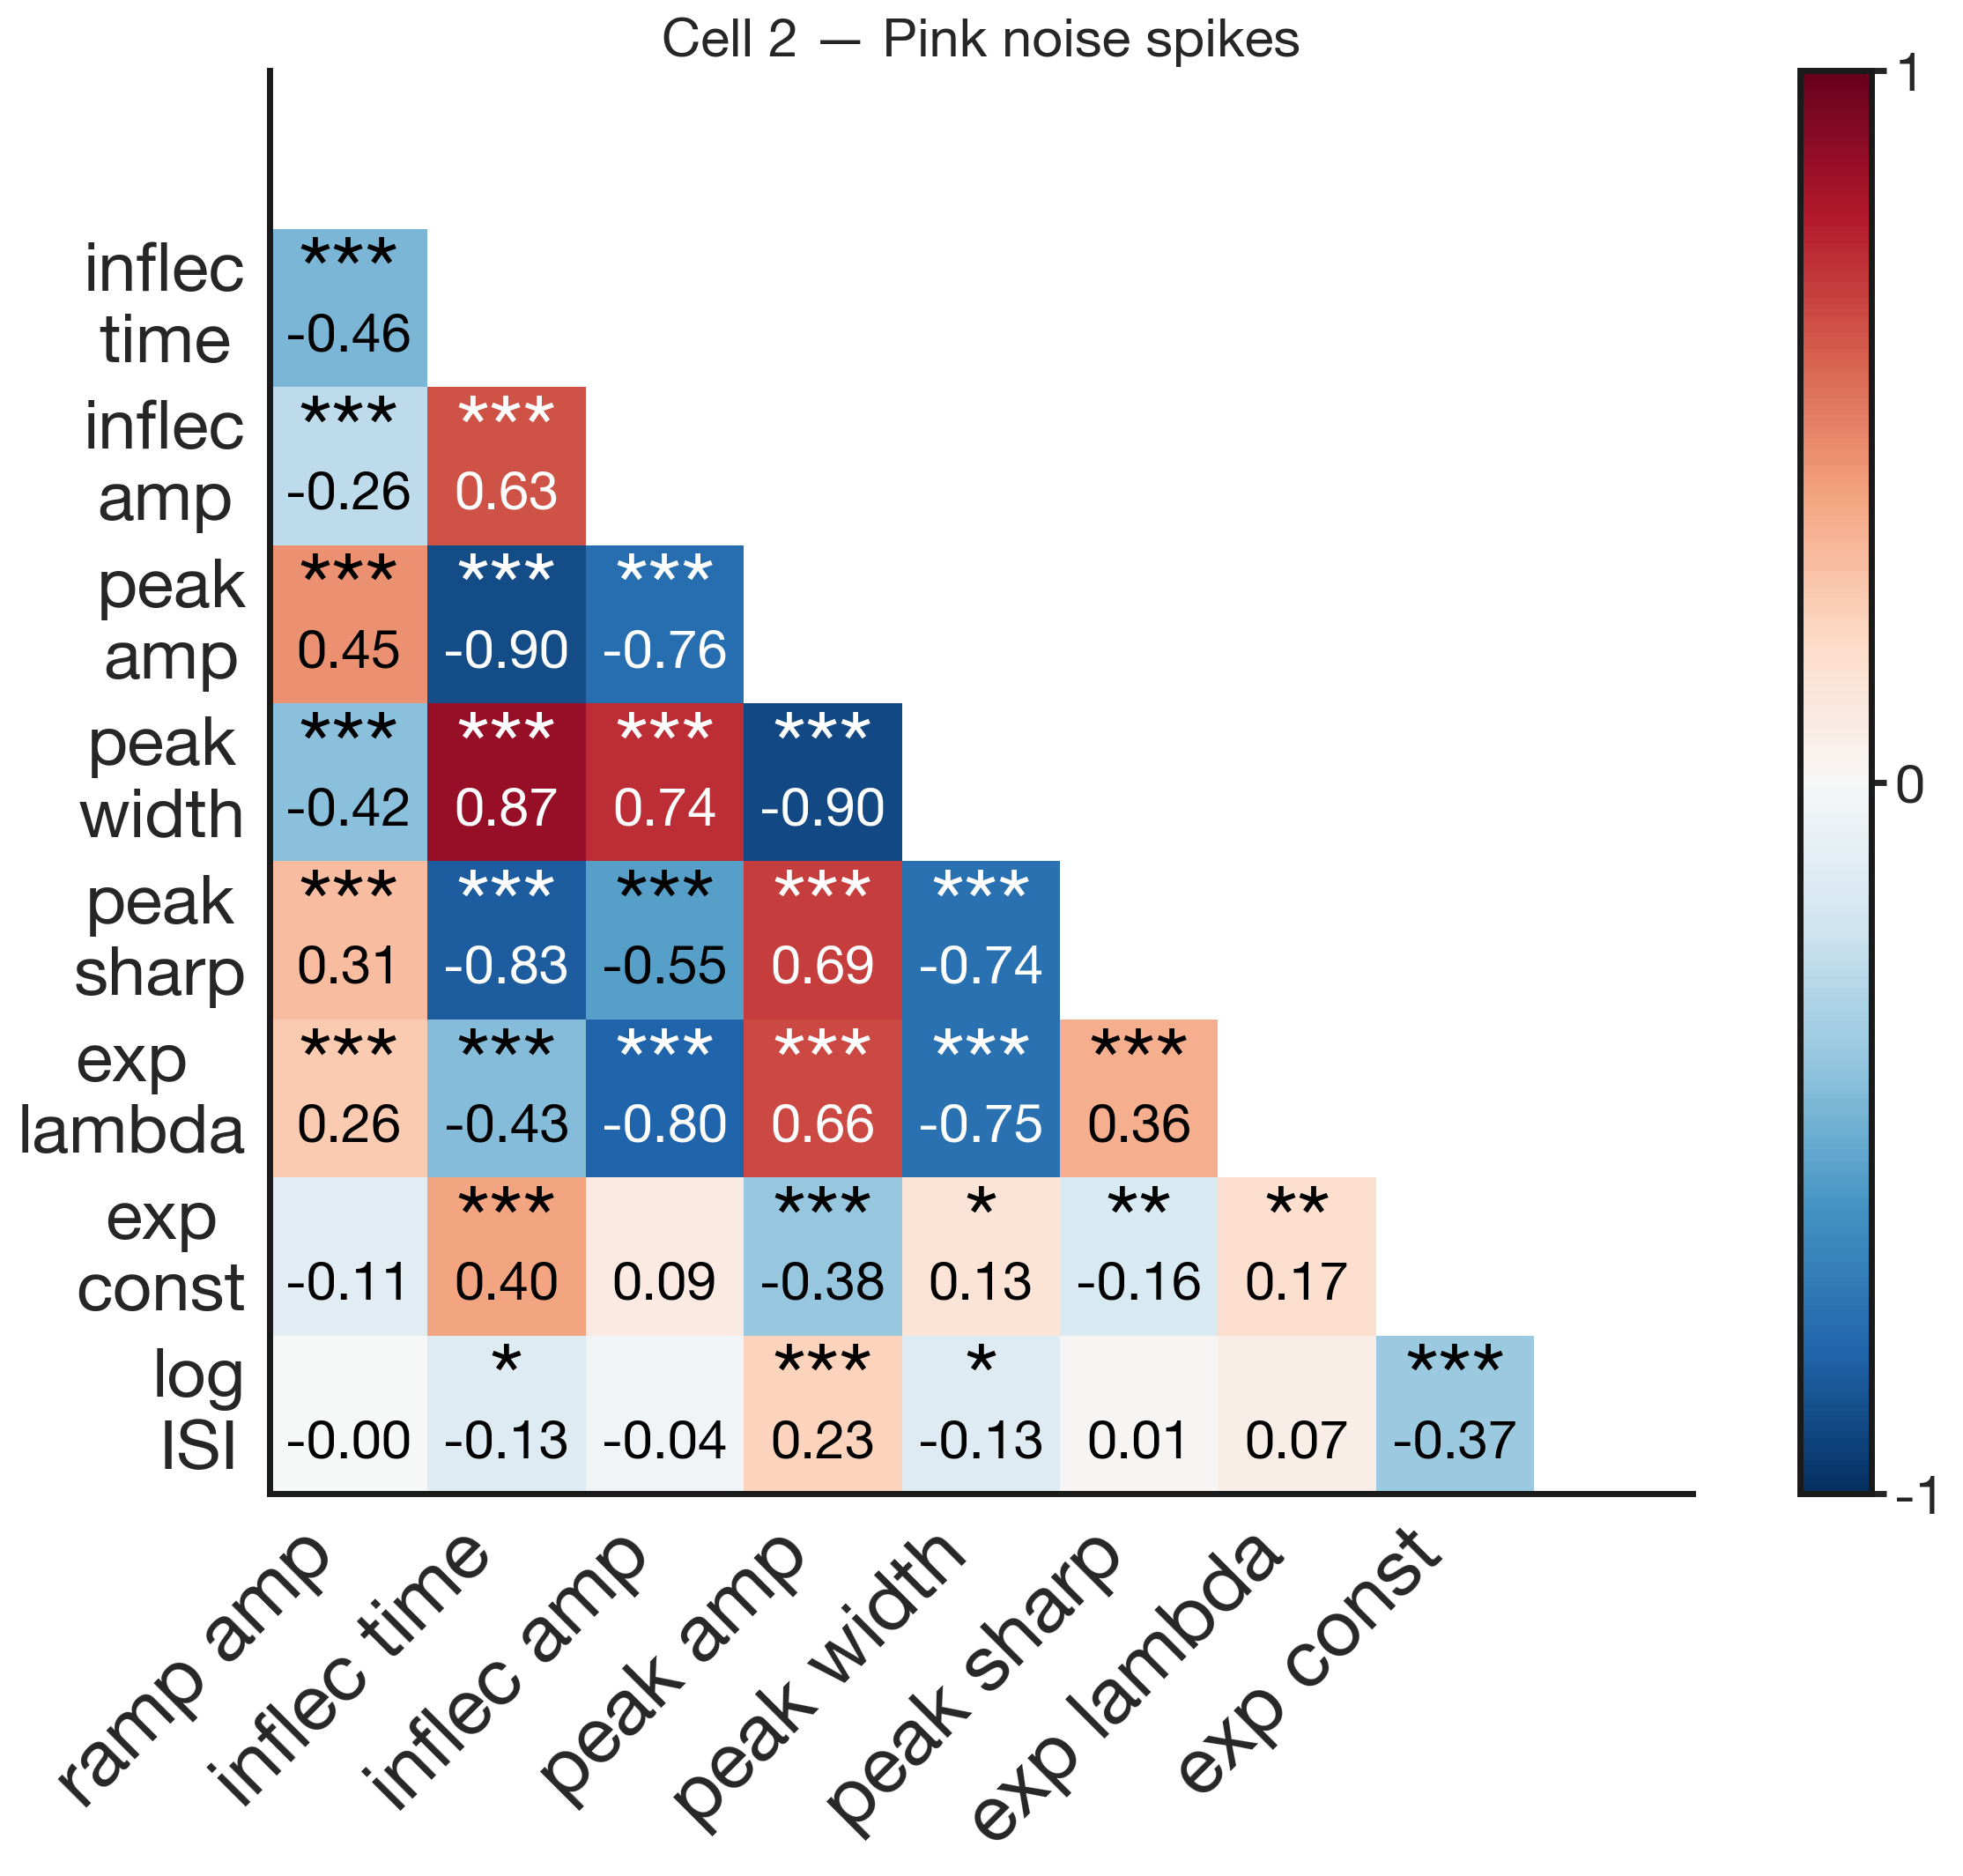

In [5]:
# Cell 2 — pink spikes only (pre-filtered, all spike features incl. log ISI)
_drop = ['sweep', 'stim_type', 'pink_type', 'spike_num']
df_pink_c2 = df_pink_filt_c2.drop(_drop, axis=1, errors='ignore')
spike_features_c2 = [c for c in df_pink_c2.columns
                     if c not in ('stim_exp', 'stim_mean', 'stim_std')]
plot_corr_heatmap_only_spk(df_pink_c2, spike_features_c2, title='Cell 2 — Pink noise spikes')

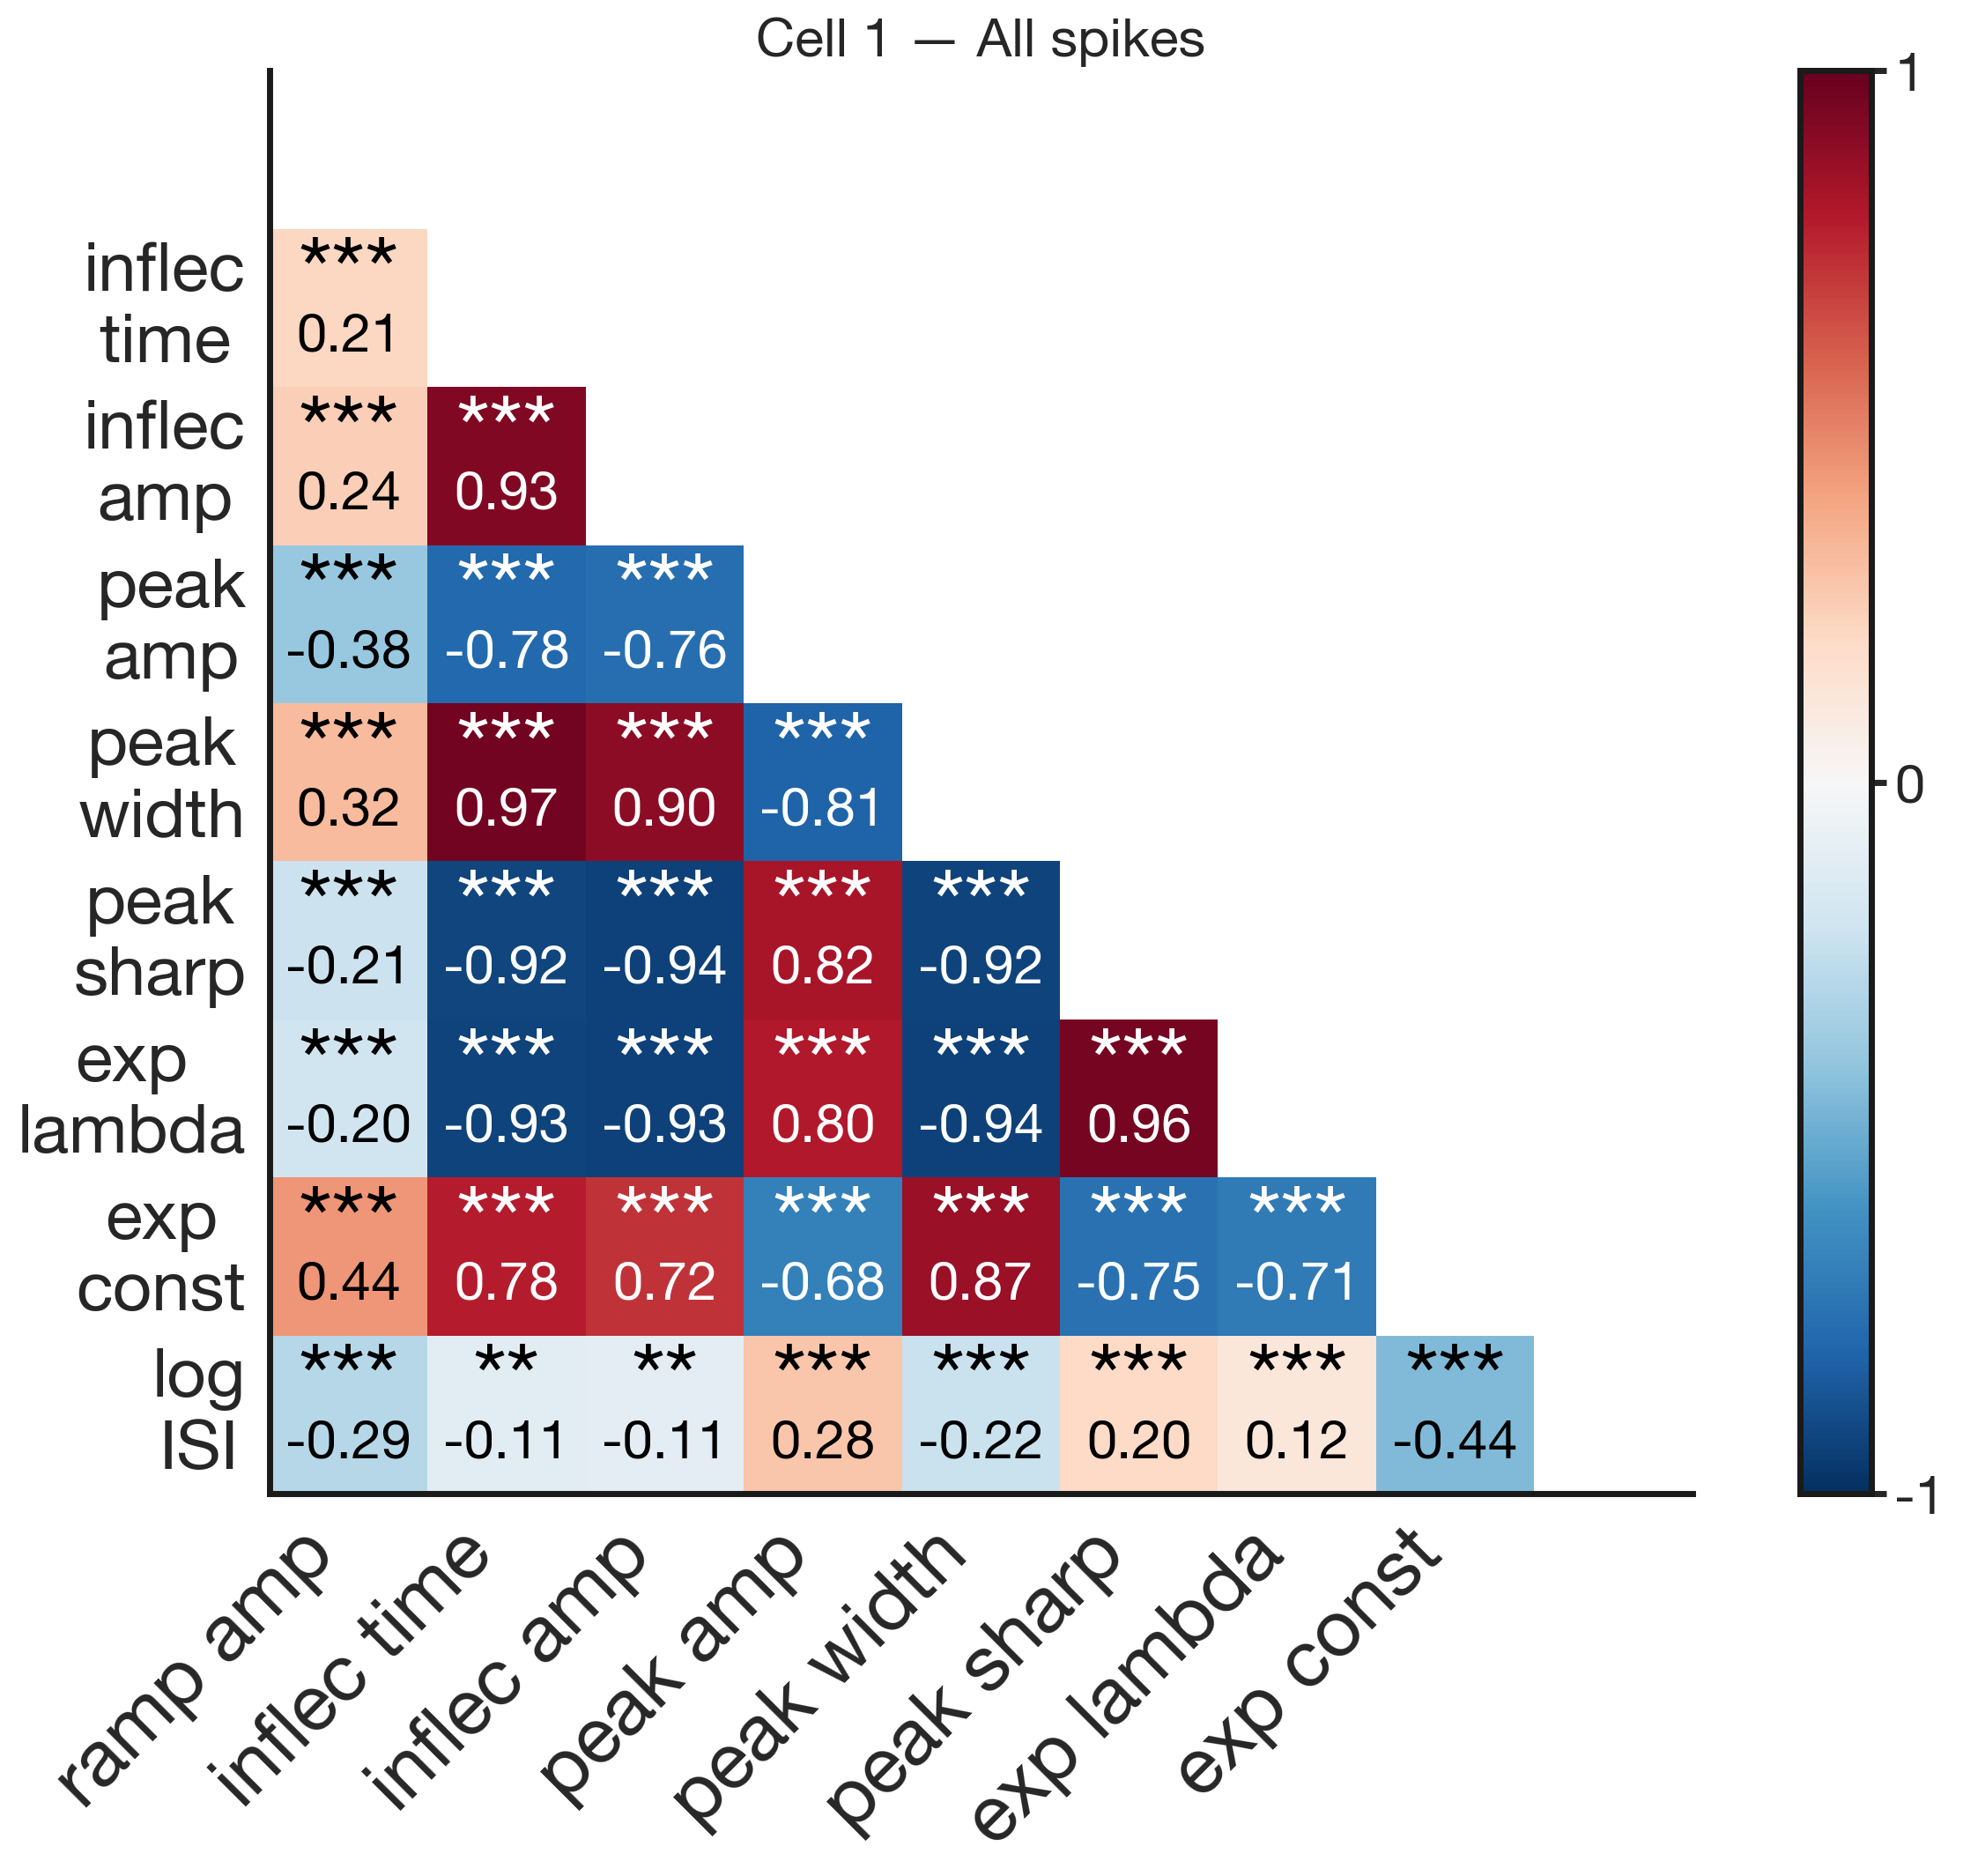

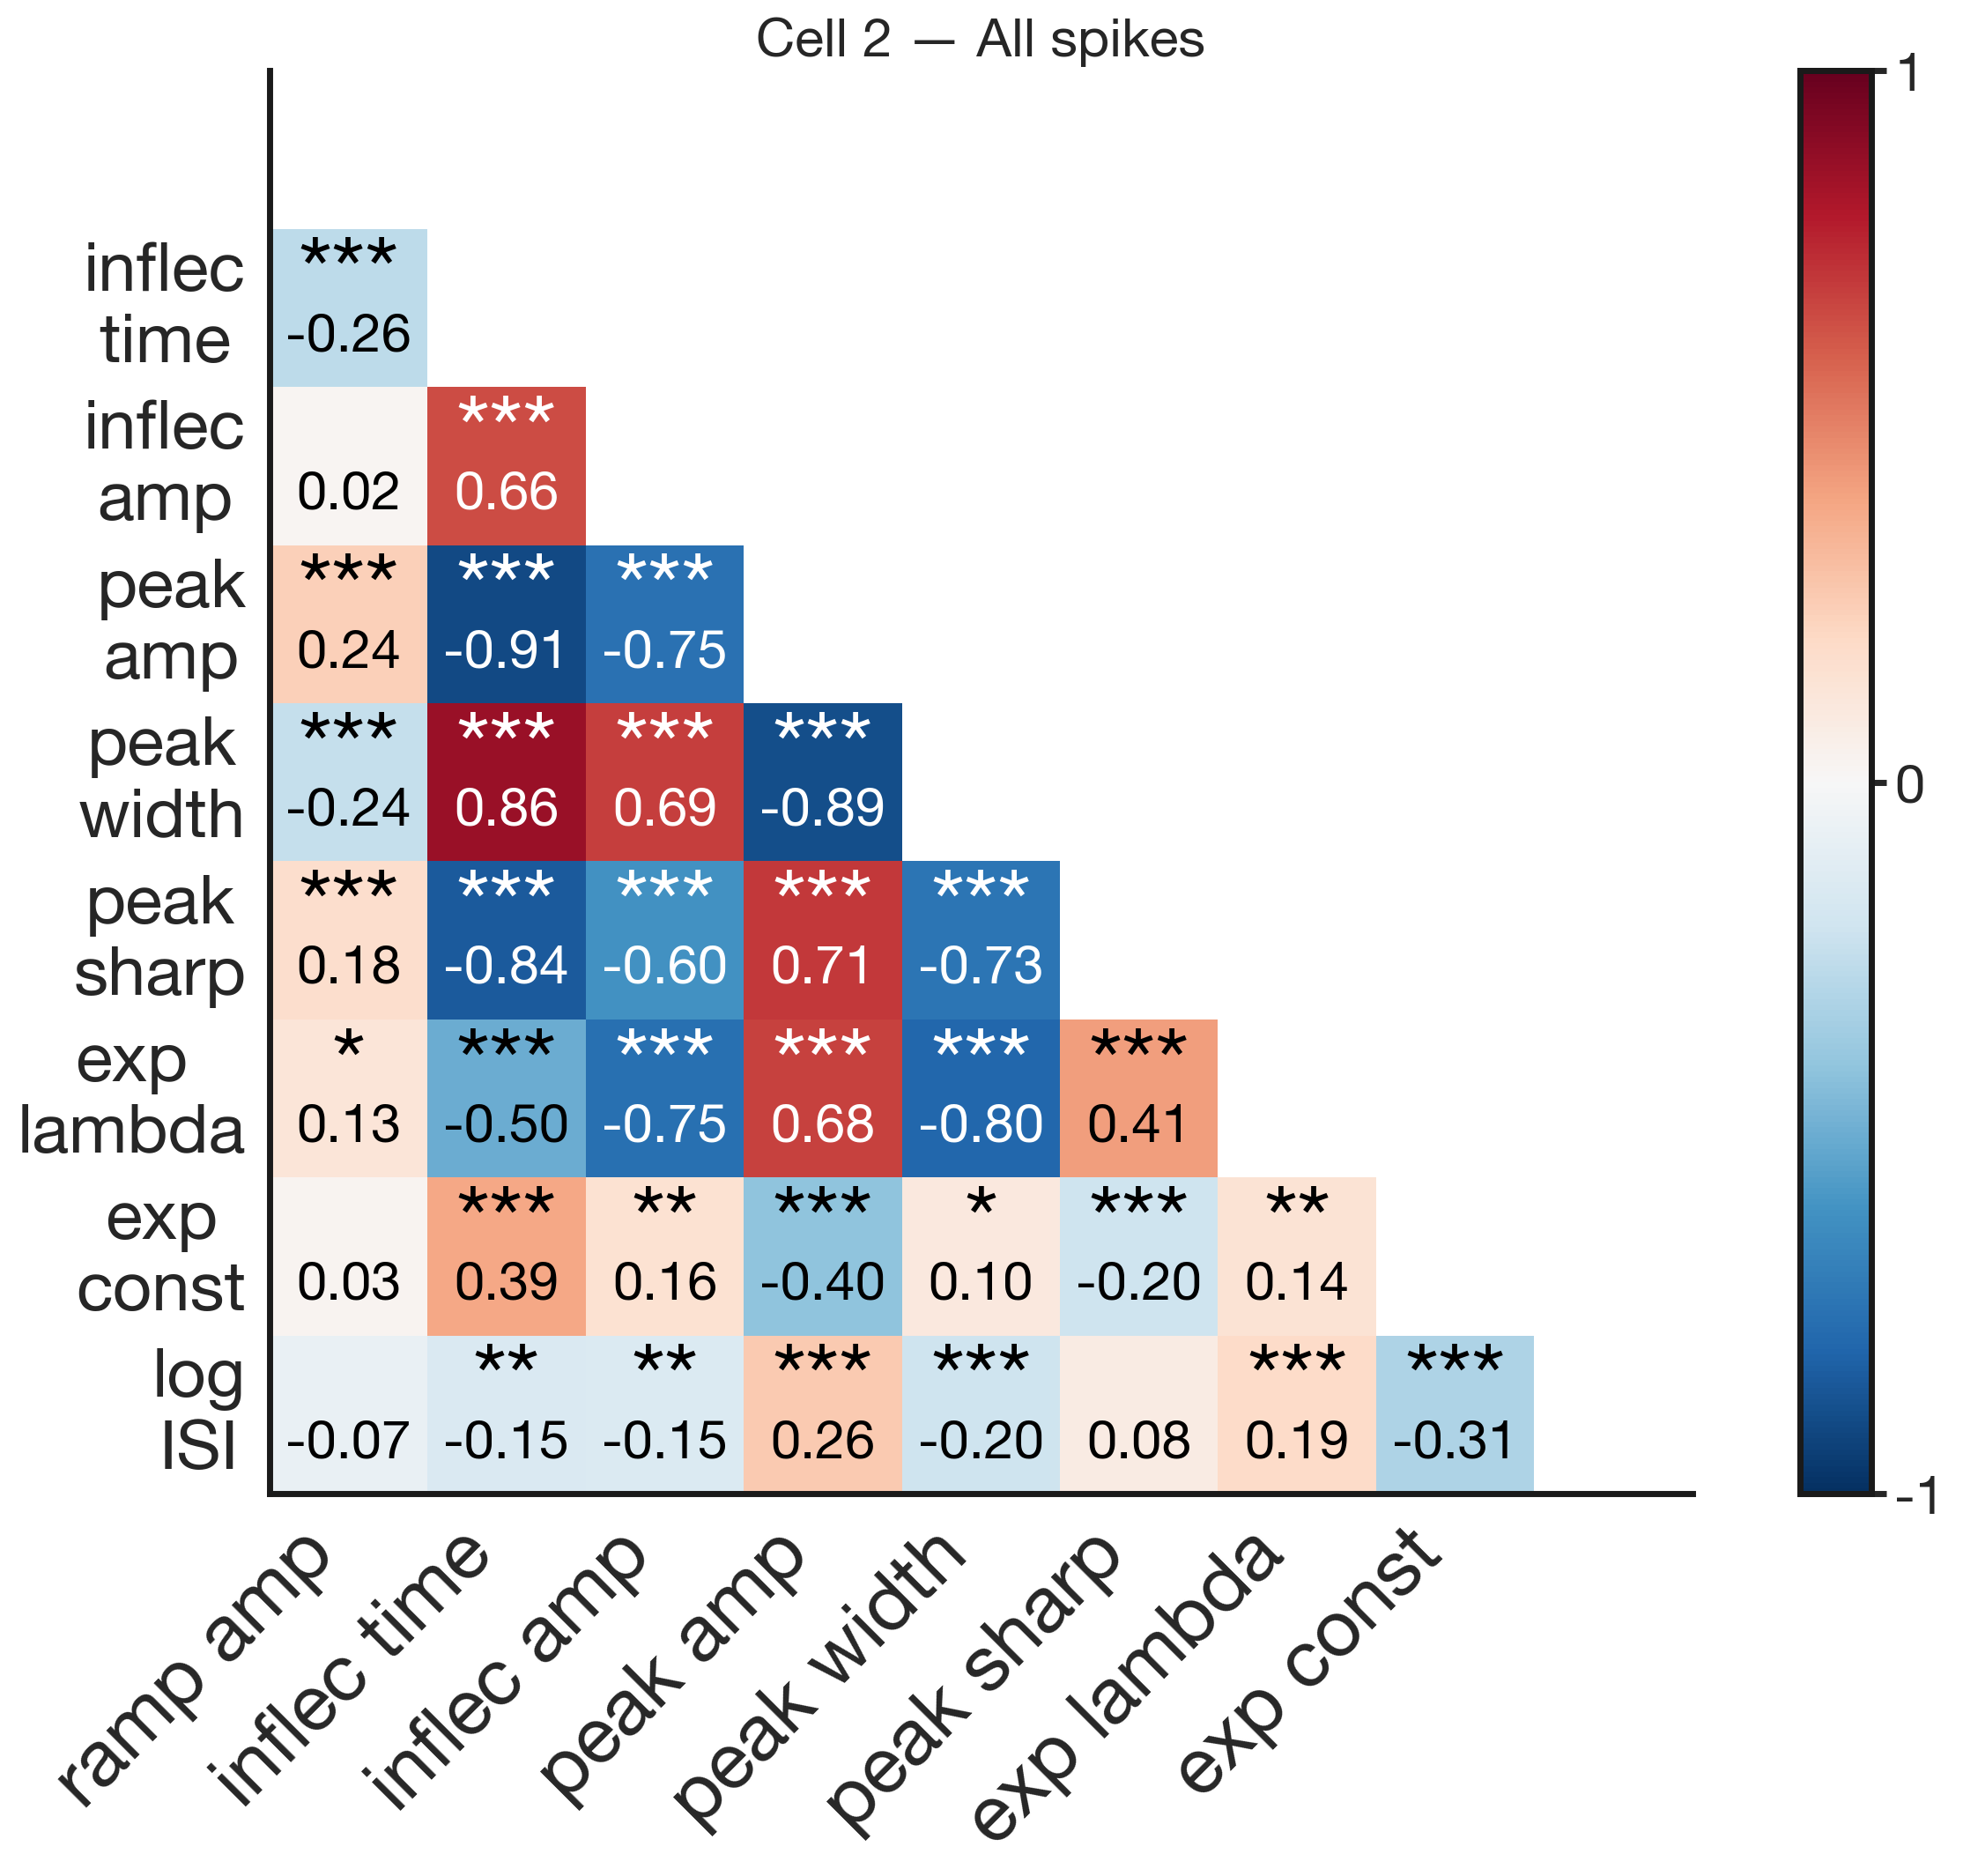

In [6]:
# Cell 1 — ALL spikes (all stim types, all spike features incl. log ISI)
_drop = ['sweep', 'stim_type', 'pink_type', 'spike_num']
df_all_spk_c1 = df_all_c1.drop(_drop, axis=1, errors='ignore')
spike_features_all_c1 = [c for c in df_all_spk_c1.columns
                          if c not in ('stim_exp', 'stim_mean', 'stim_std')]
plot_corr_heatmap_only_spk(df_all_spk_c1, spike_features_all_c1,
                            title='Cell 1 — All spikes')

# Cell 2 — ALL spikes
df_all_spk_c2 = df_all_c2.drop(_drop, axis=1, errors='ignore')
spike_features_all_c2 = [c for c in df_all_spk_c2.columns
                          if c not in ('stim_exp', 'stim_mean', 'stim_std')]
plot_corr_heatmap_only_spk(df_all_spk_c2, spike_features_all_c2,
                            title='Cell 2 — All spikes')

## Fig S2 — Bootstrap Accuracy Distributions

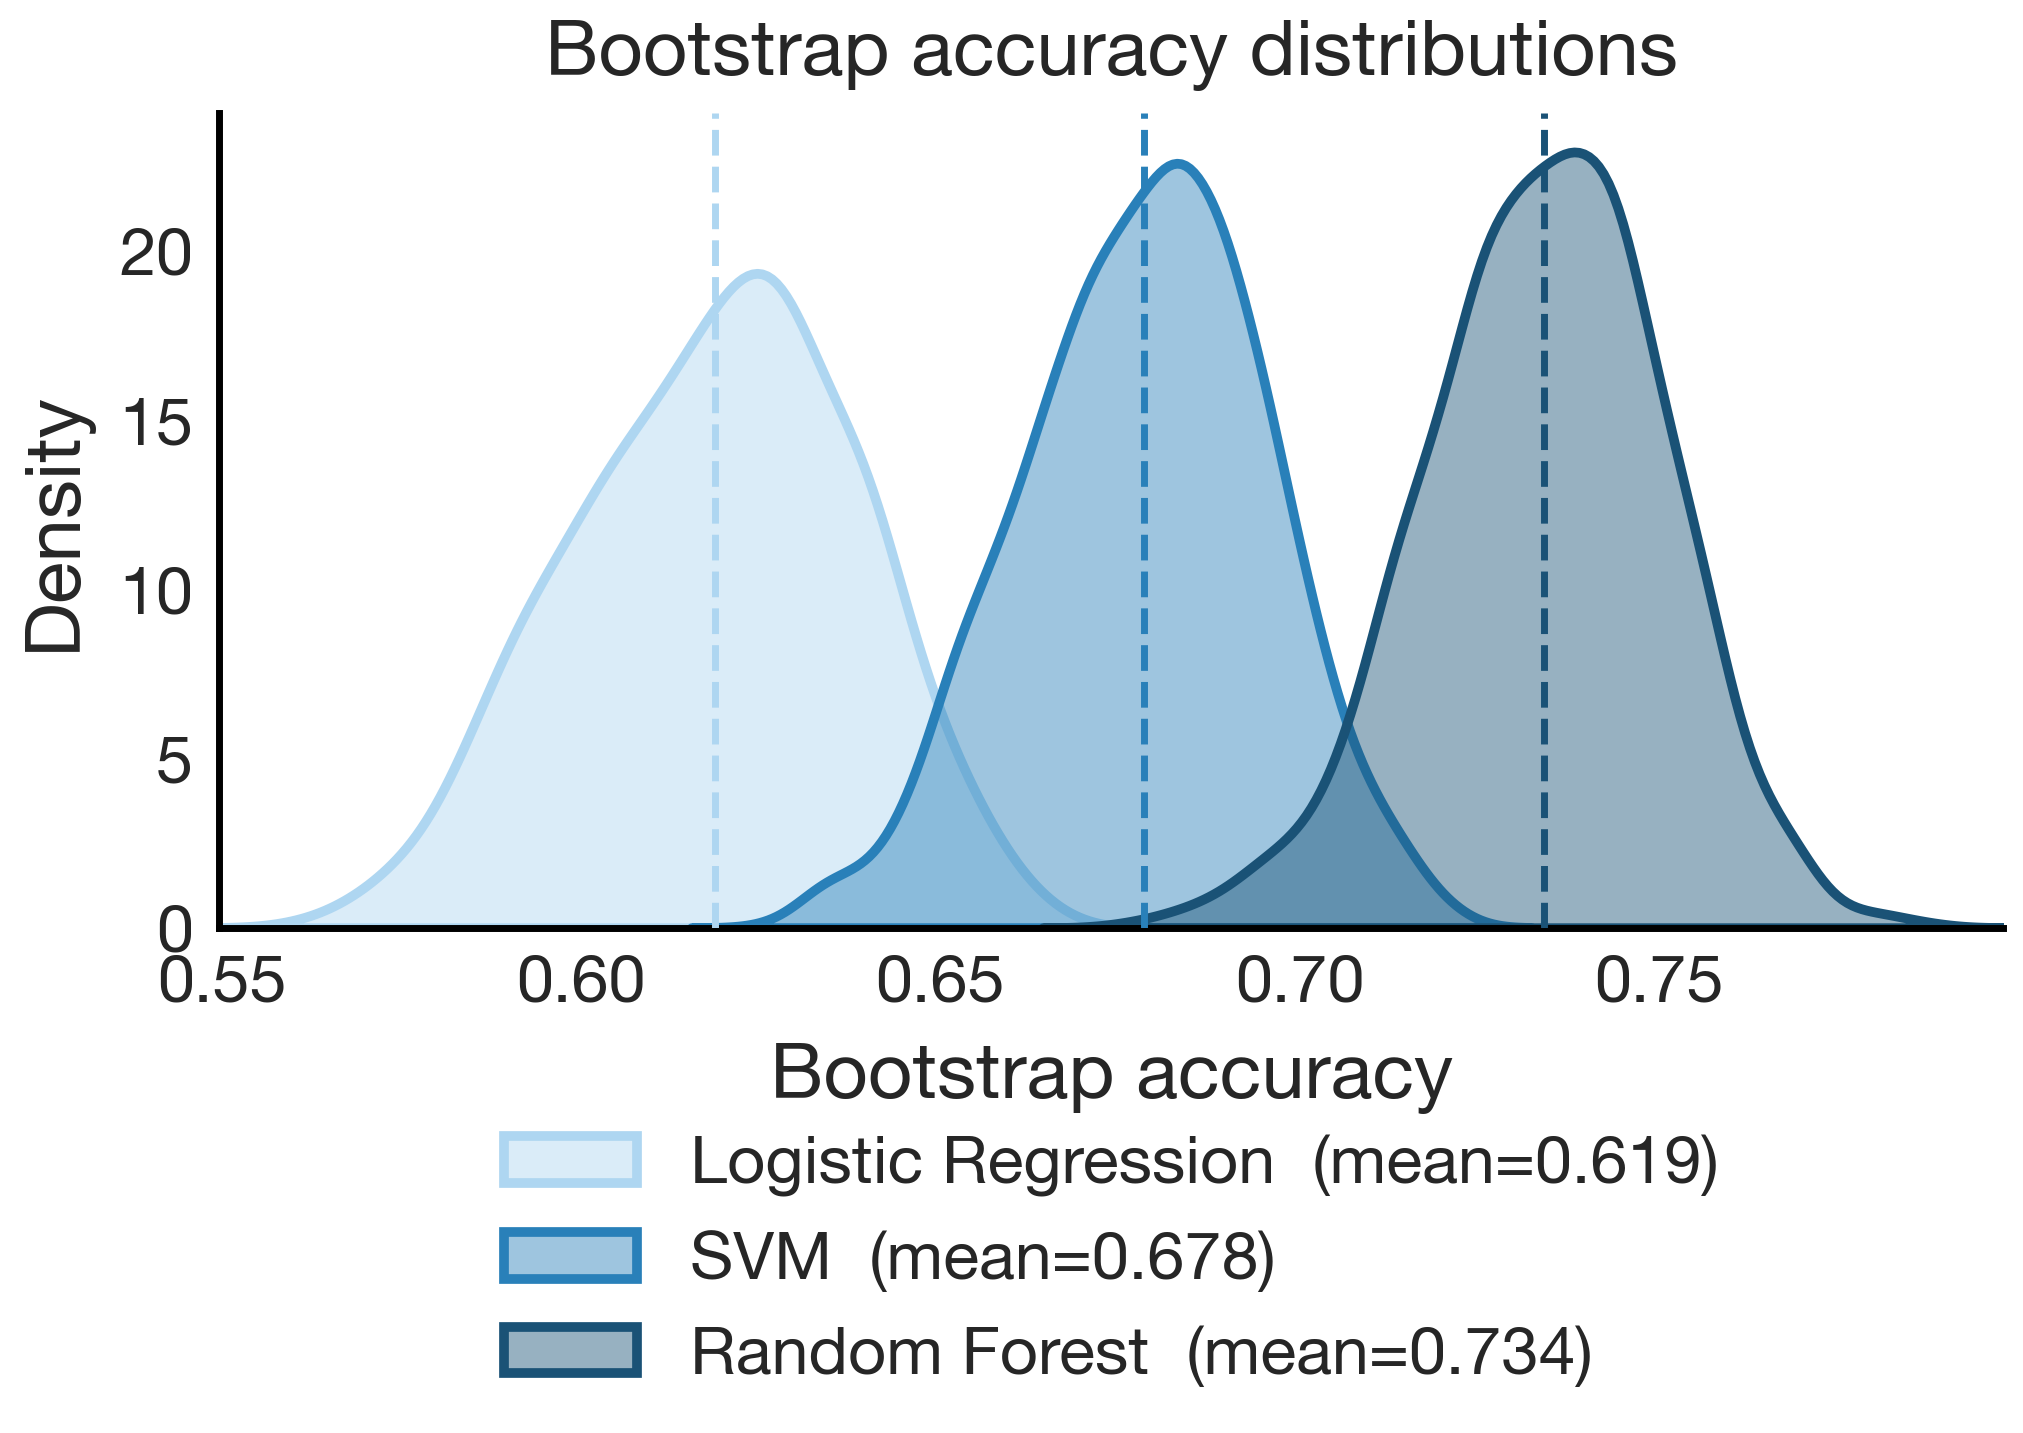

In [7]:
# Cell 1 — KDE overlay only
plot_bootstrap_histograms([logr_accs_c1, svm_accs_c1, rf_accs_c1],
                          ['Logistic Regression', 'SVM', 'Random Forest'], overlay=True)

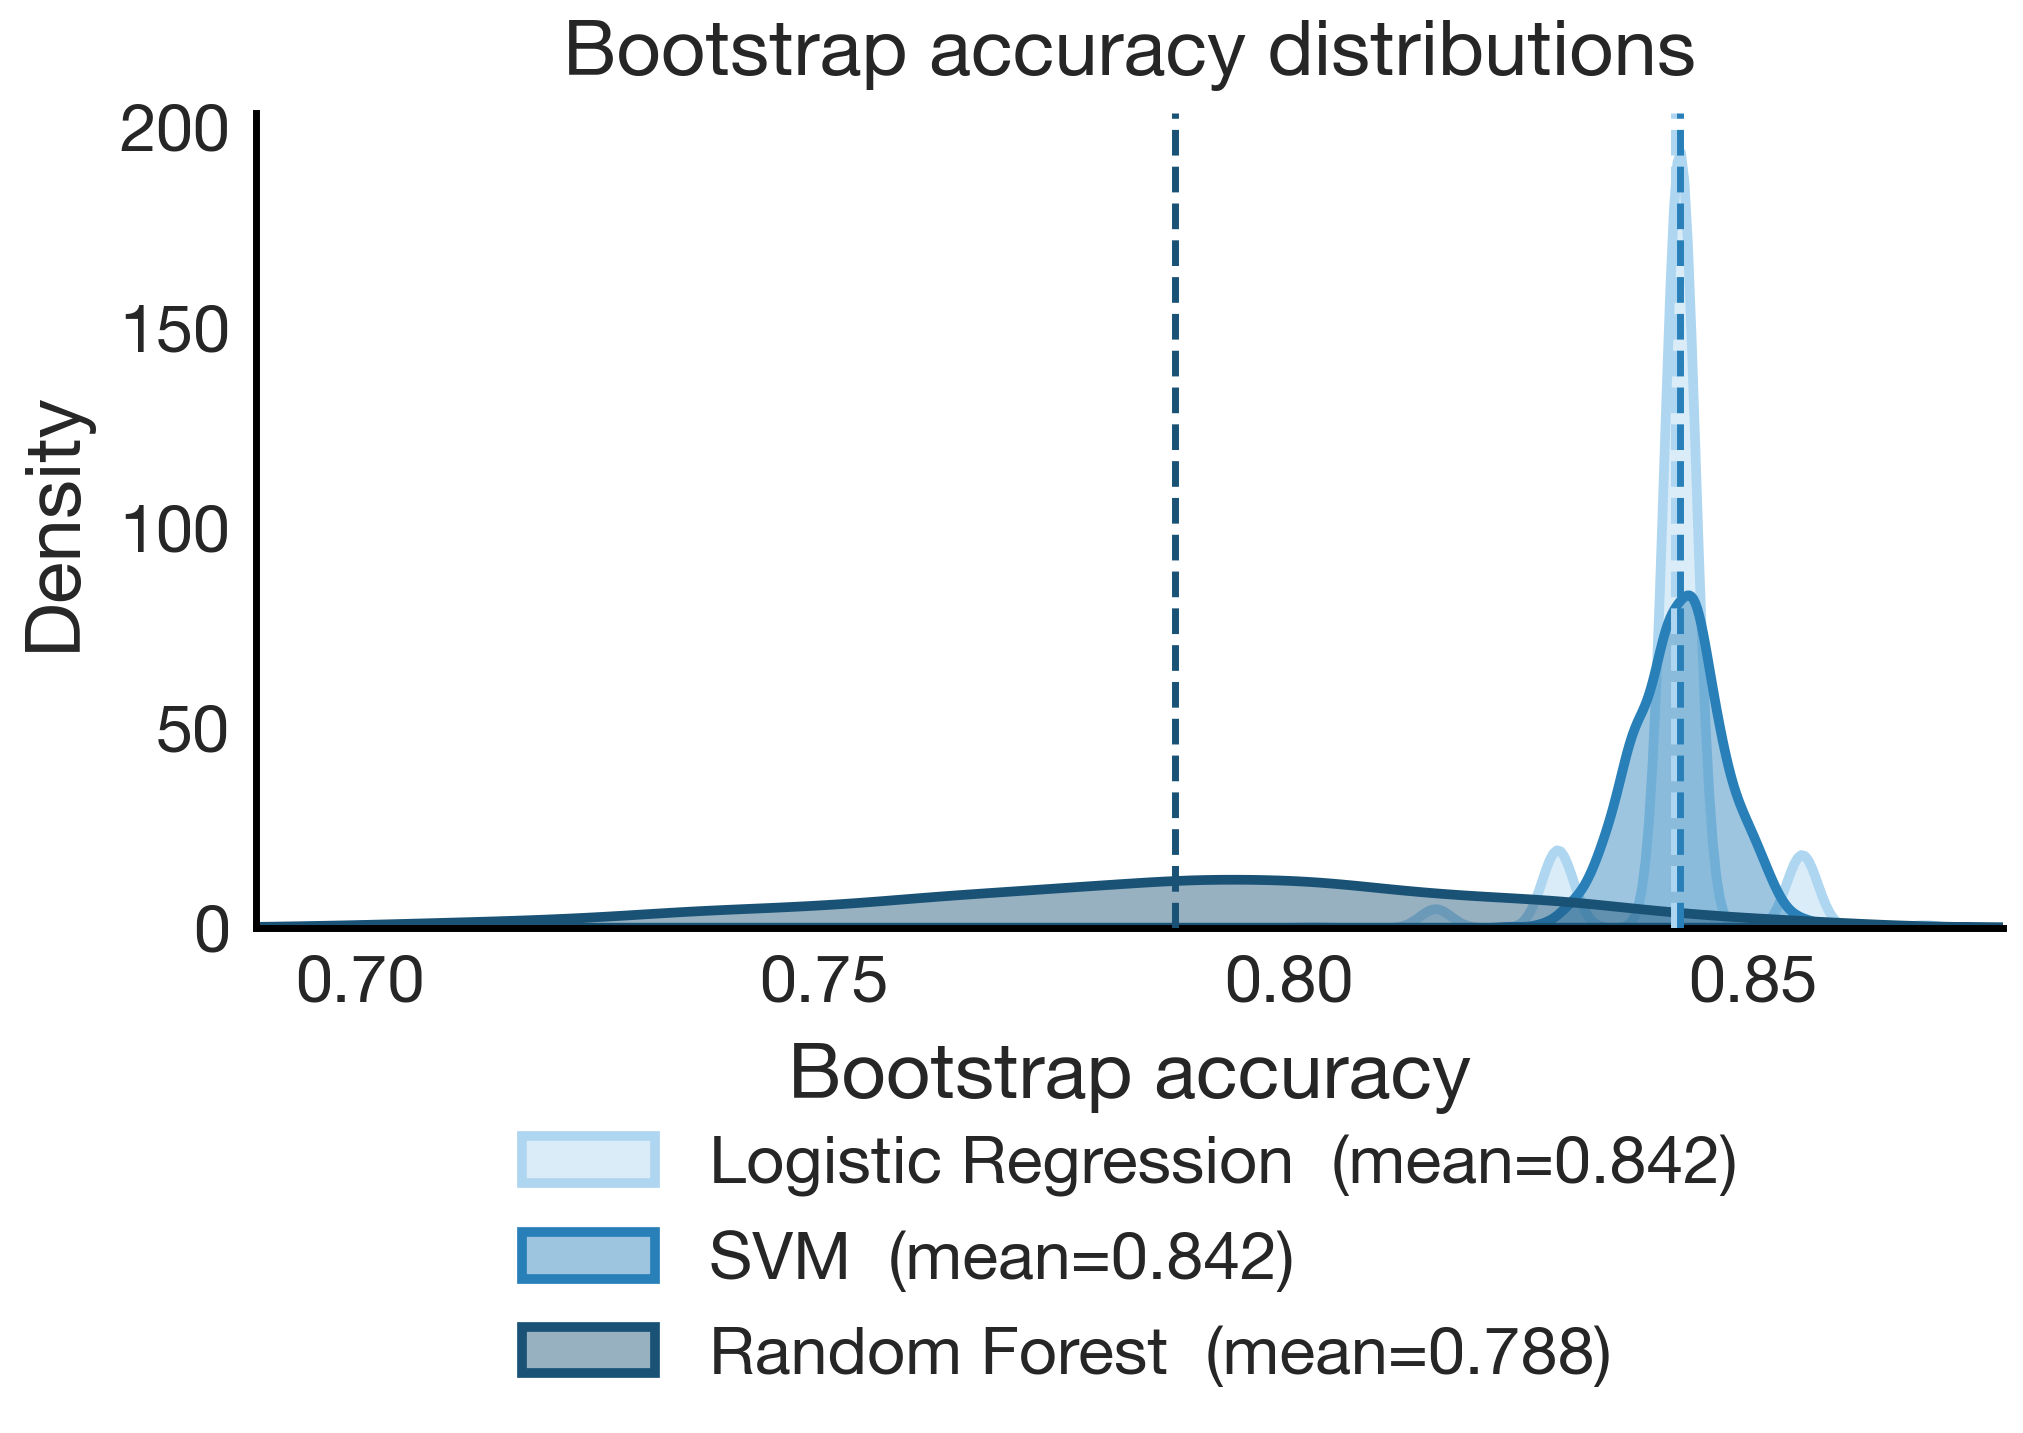

In [8]:
# Cell 2 — binary (constant vs. pink), KDE overlay
plot_bootstrap_histograms([logr_accs_c2_bin, svm_accs_c2_bin, rf_accs_c2_bin],
                          ['Logistic Regression', 'SVM', 'Random Forest'], overlay=True)

## Fig S3 — Window Expansion (R² vs. pre-spike window)

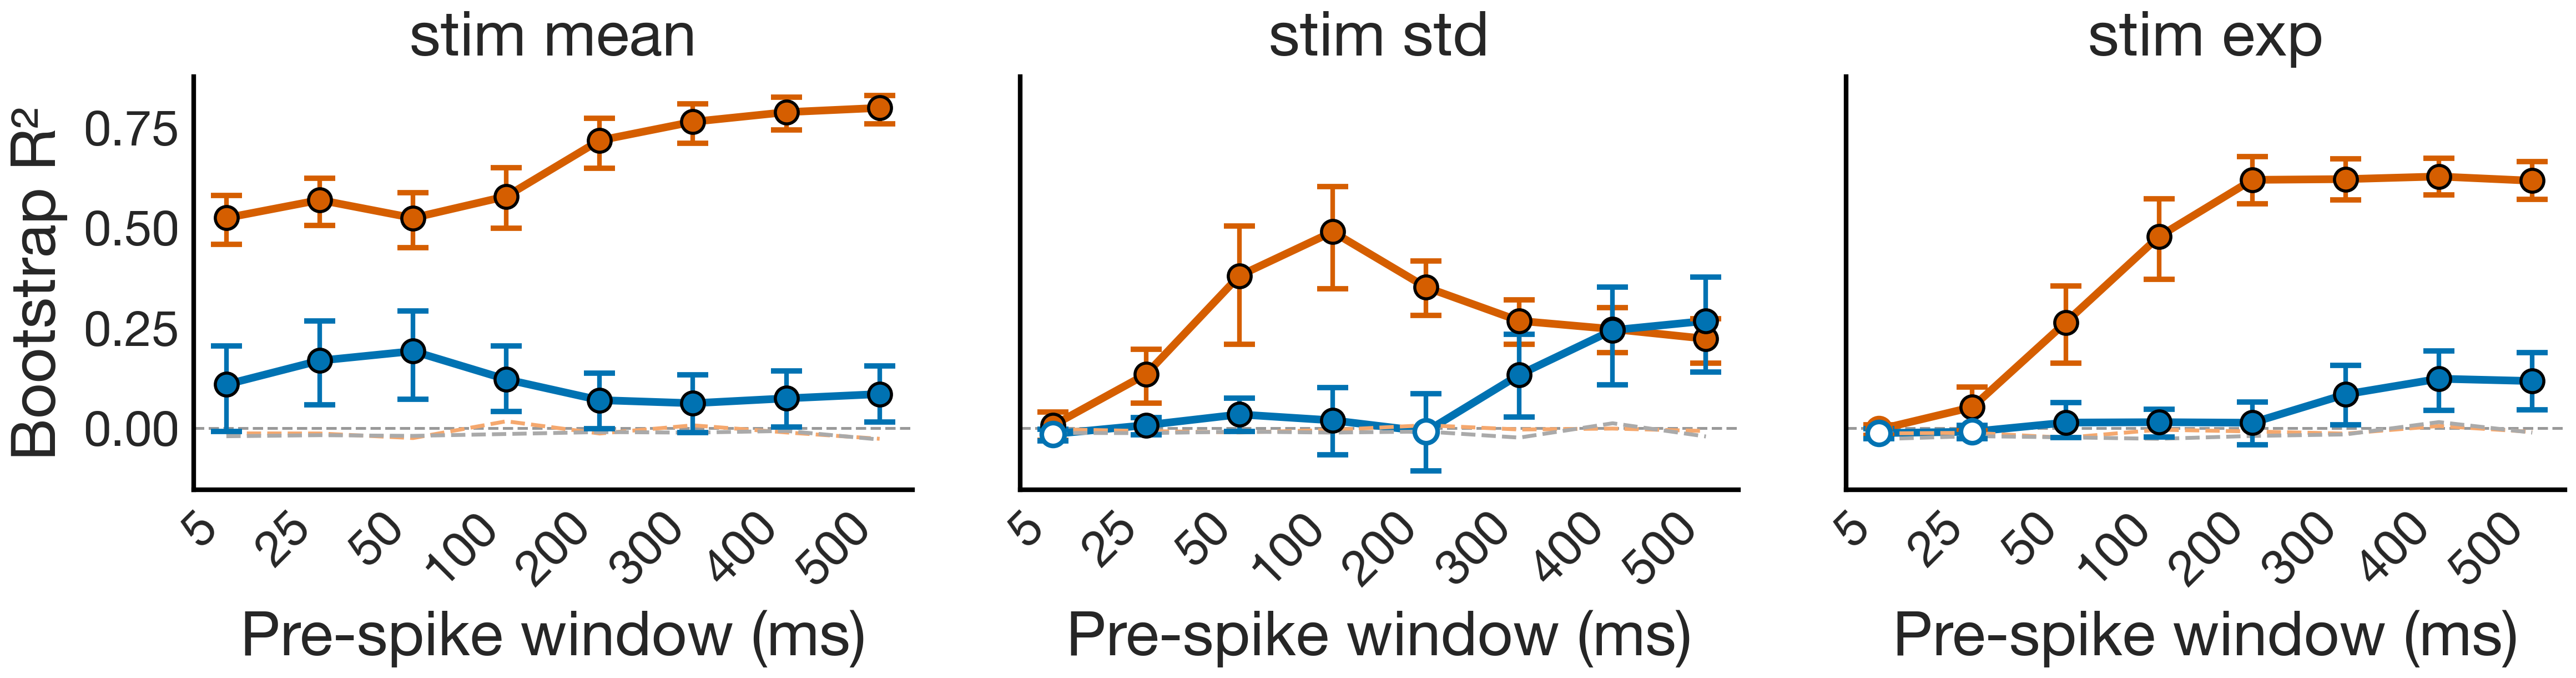

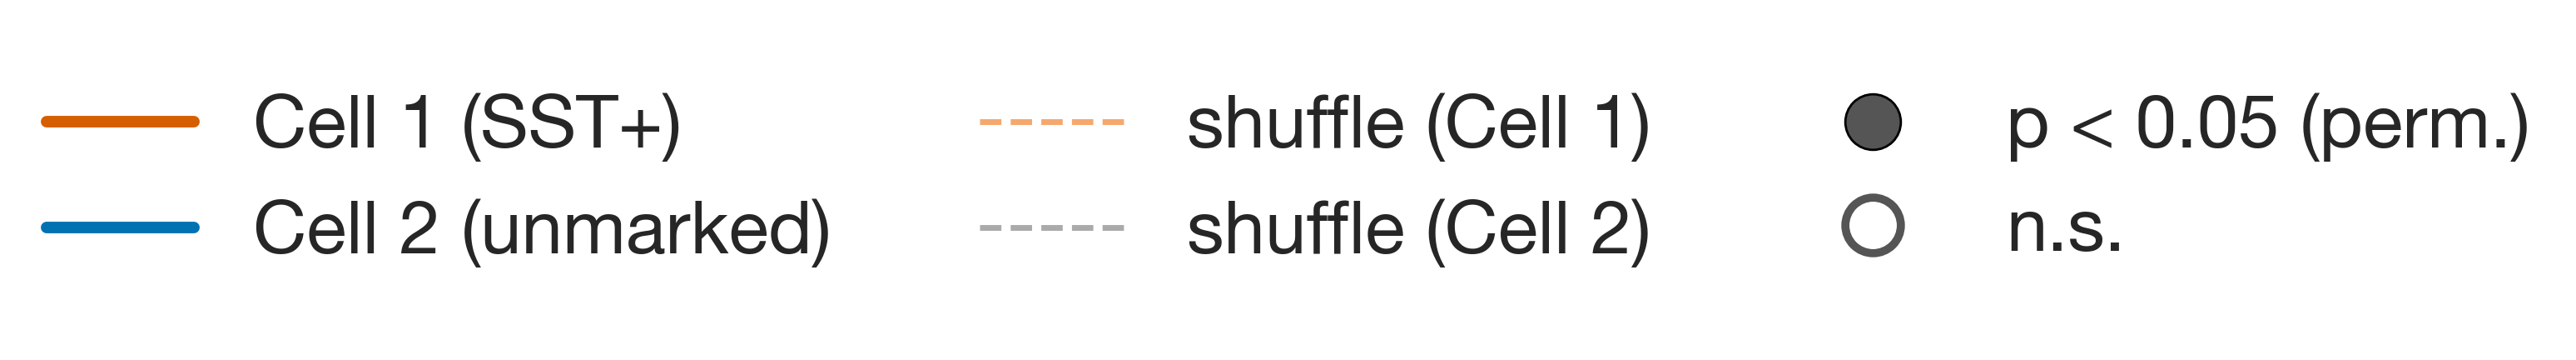

In [9]:
_shuf_c1 = {f'{w}ms_{t}': results_win_c1[f'shuf_{w}ms_{t}']
            for w in WINDOWS_MS for t in ['stim_mean', 'stim_std', 'stim_exp']
            if f'shuf_{w}ms_{t}' in results_win_c1} or None

_shuf_c2 = {f'{w}ms_{t}': results_win_c2[f'shuf_{w}ms_{t}']
            for w in WINDOWS_MS for t in ['stim_mean', 'stim_std', 'stim_exp']
            if f'shuf_{w}ms_{t}' in results_win_c2} or None

plot_window_expansion(
    results_win_c1, WINDOWS_MS,
    targets=('stim_mean', 'stim_std', 'stim_exp'),
    target_labels=('stim mean', 'stim std', 'stim exp'),
    shuffle_results=_shuf_c1,
    results_by_window_2=results_win_c2,
    shuffle_results_2=_shuf_c2,
    cell_labels=('Cell 1 (SST+)', 'Cell 2 (unmarked)'),
)

## Fig S4 — Beta Weights

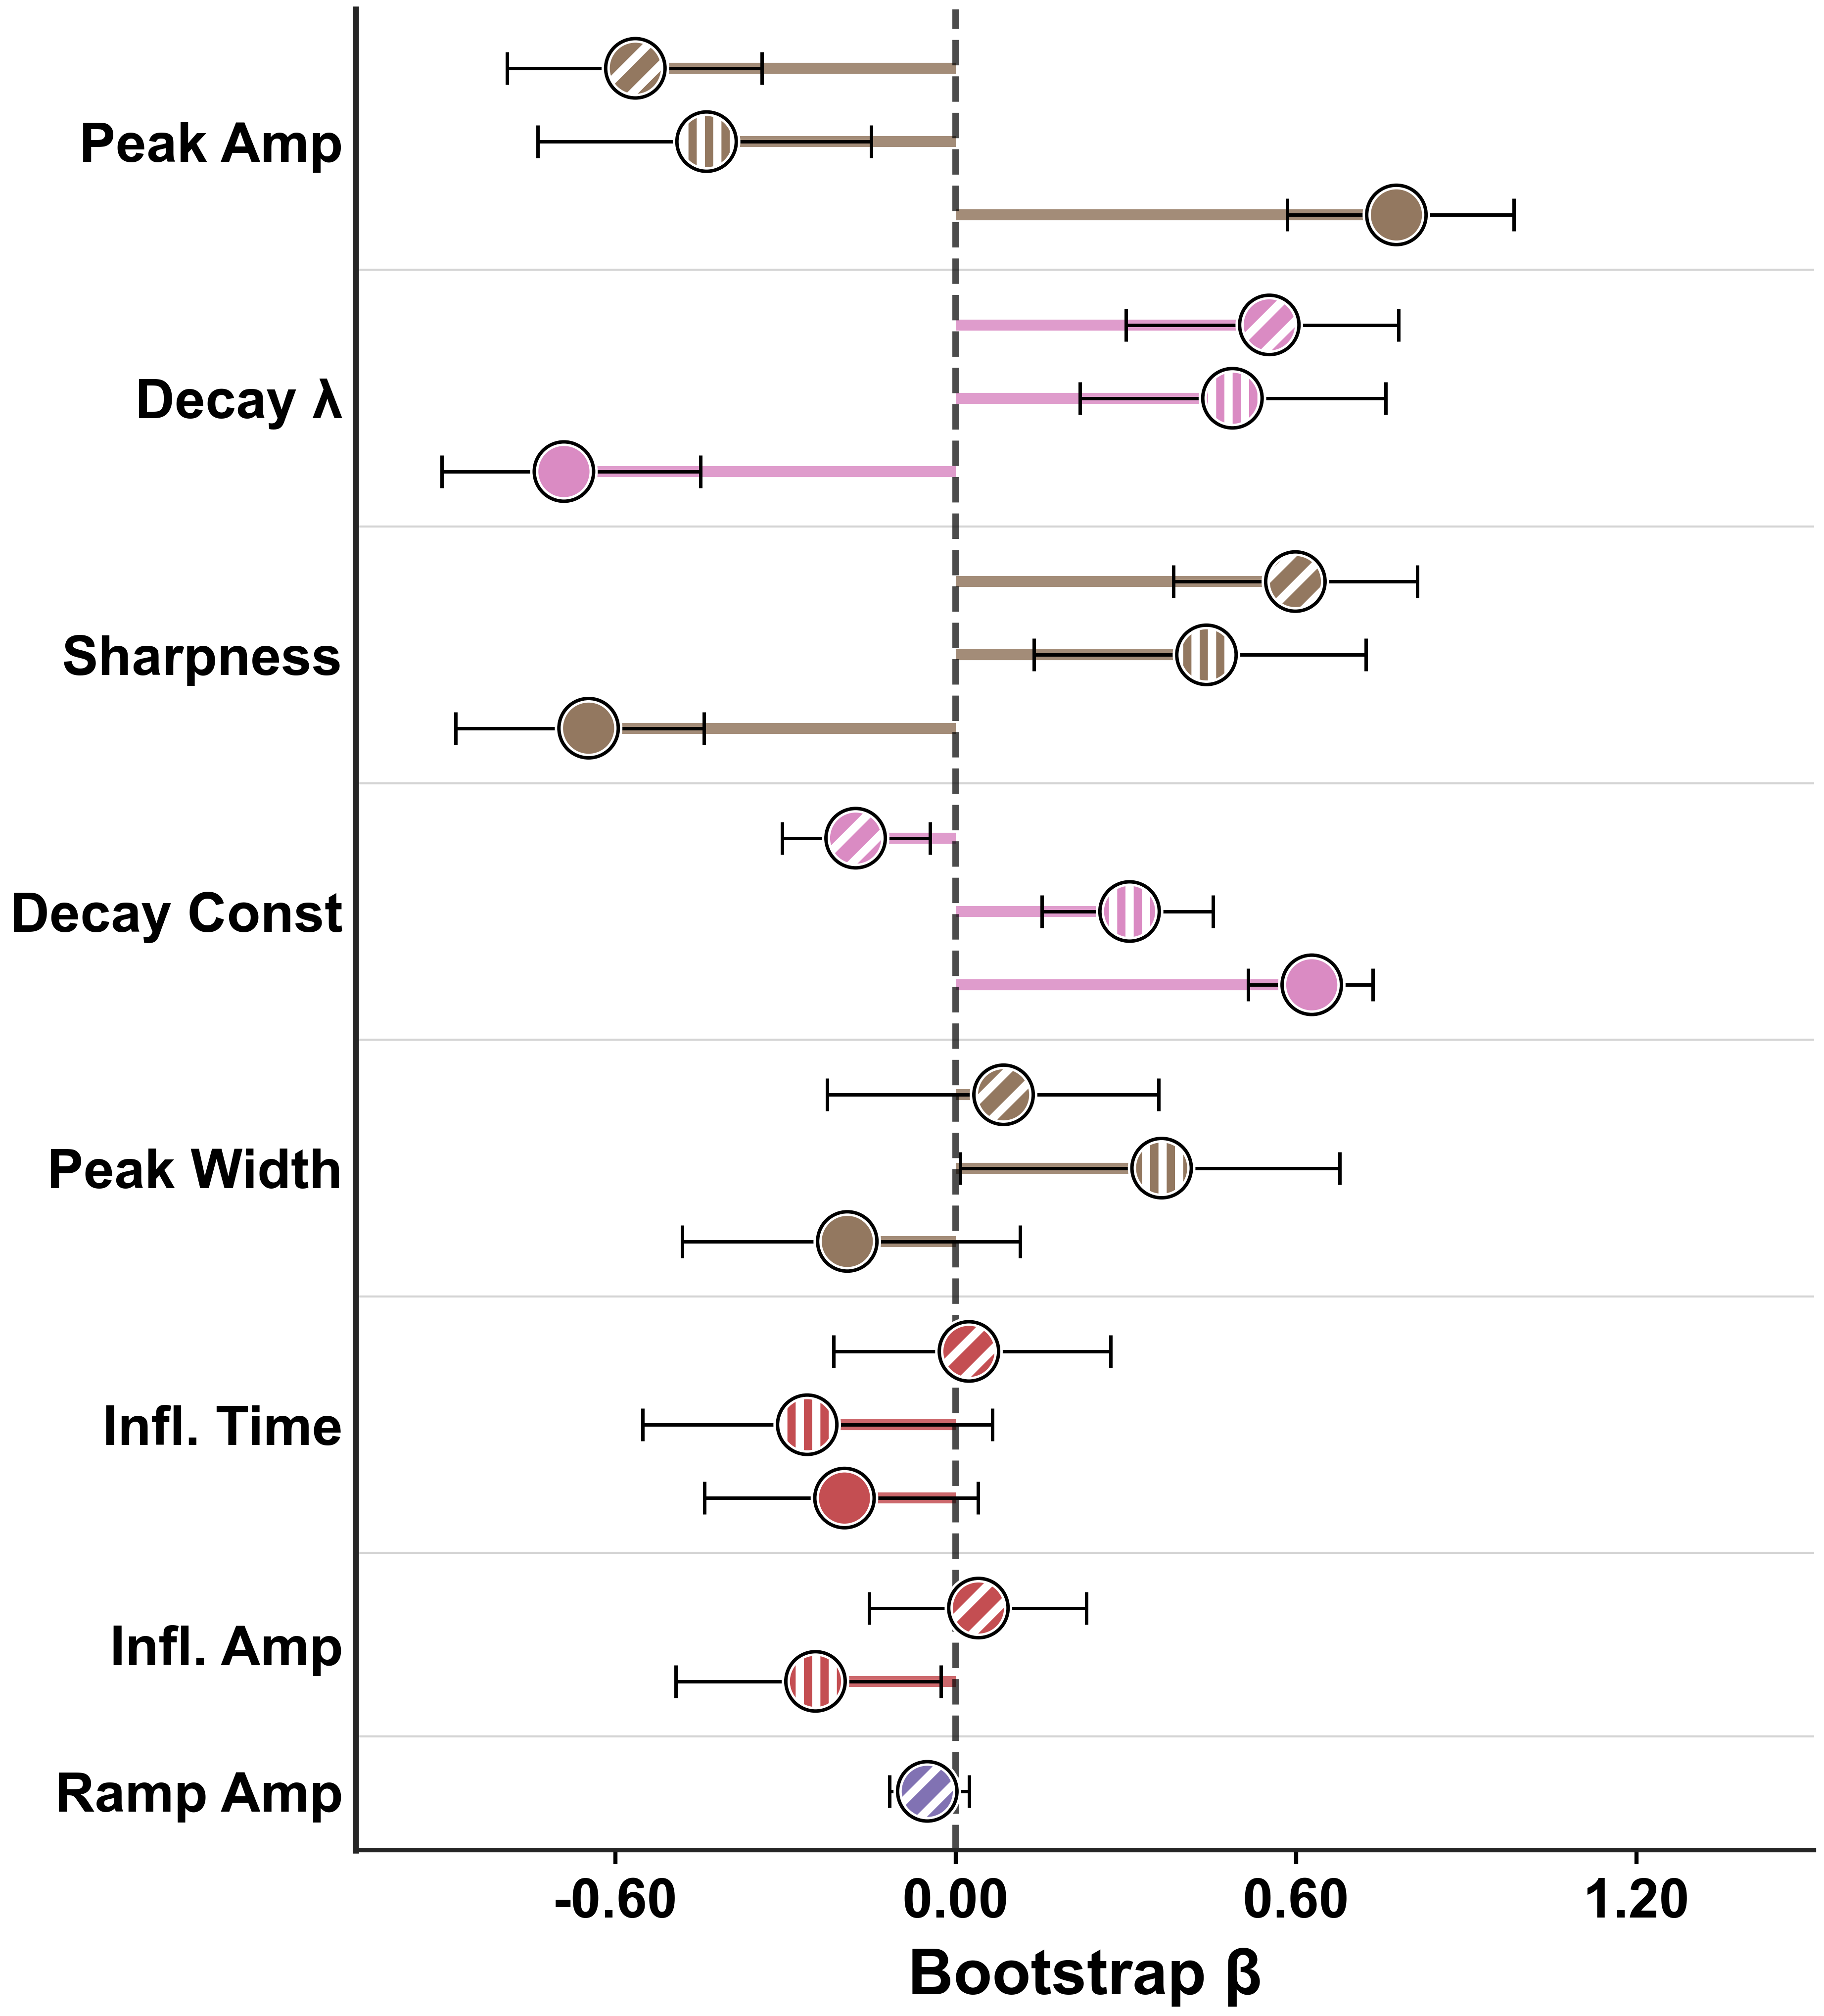

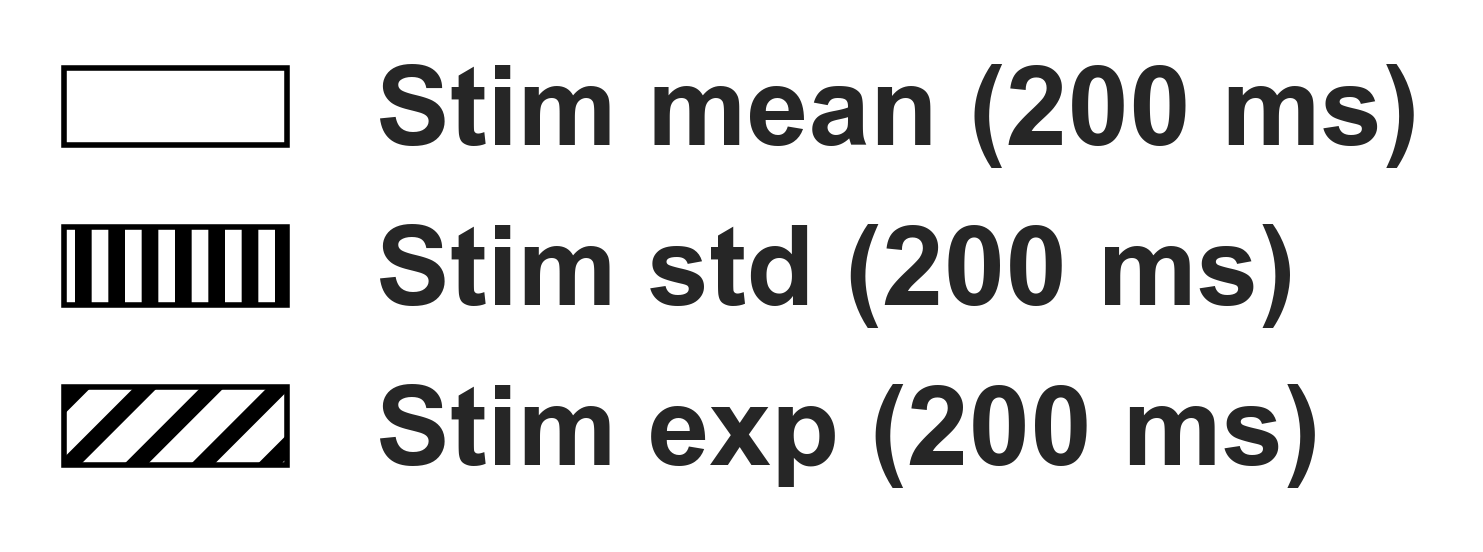

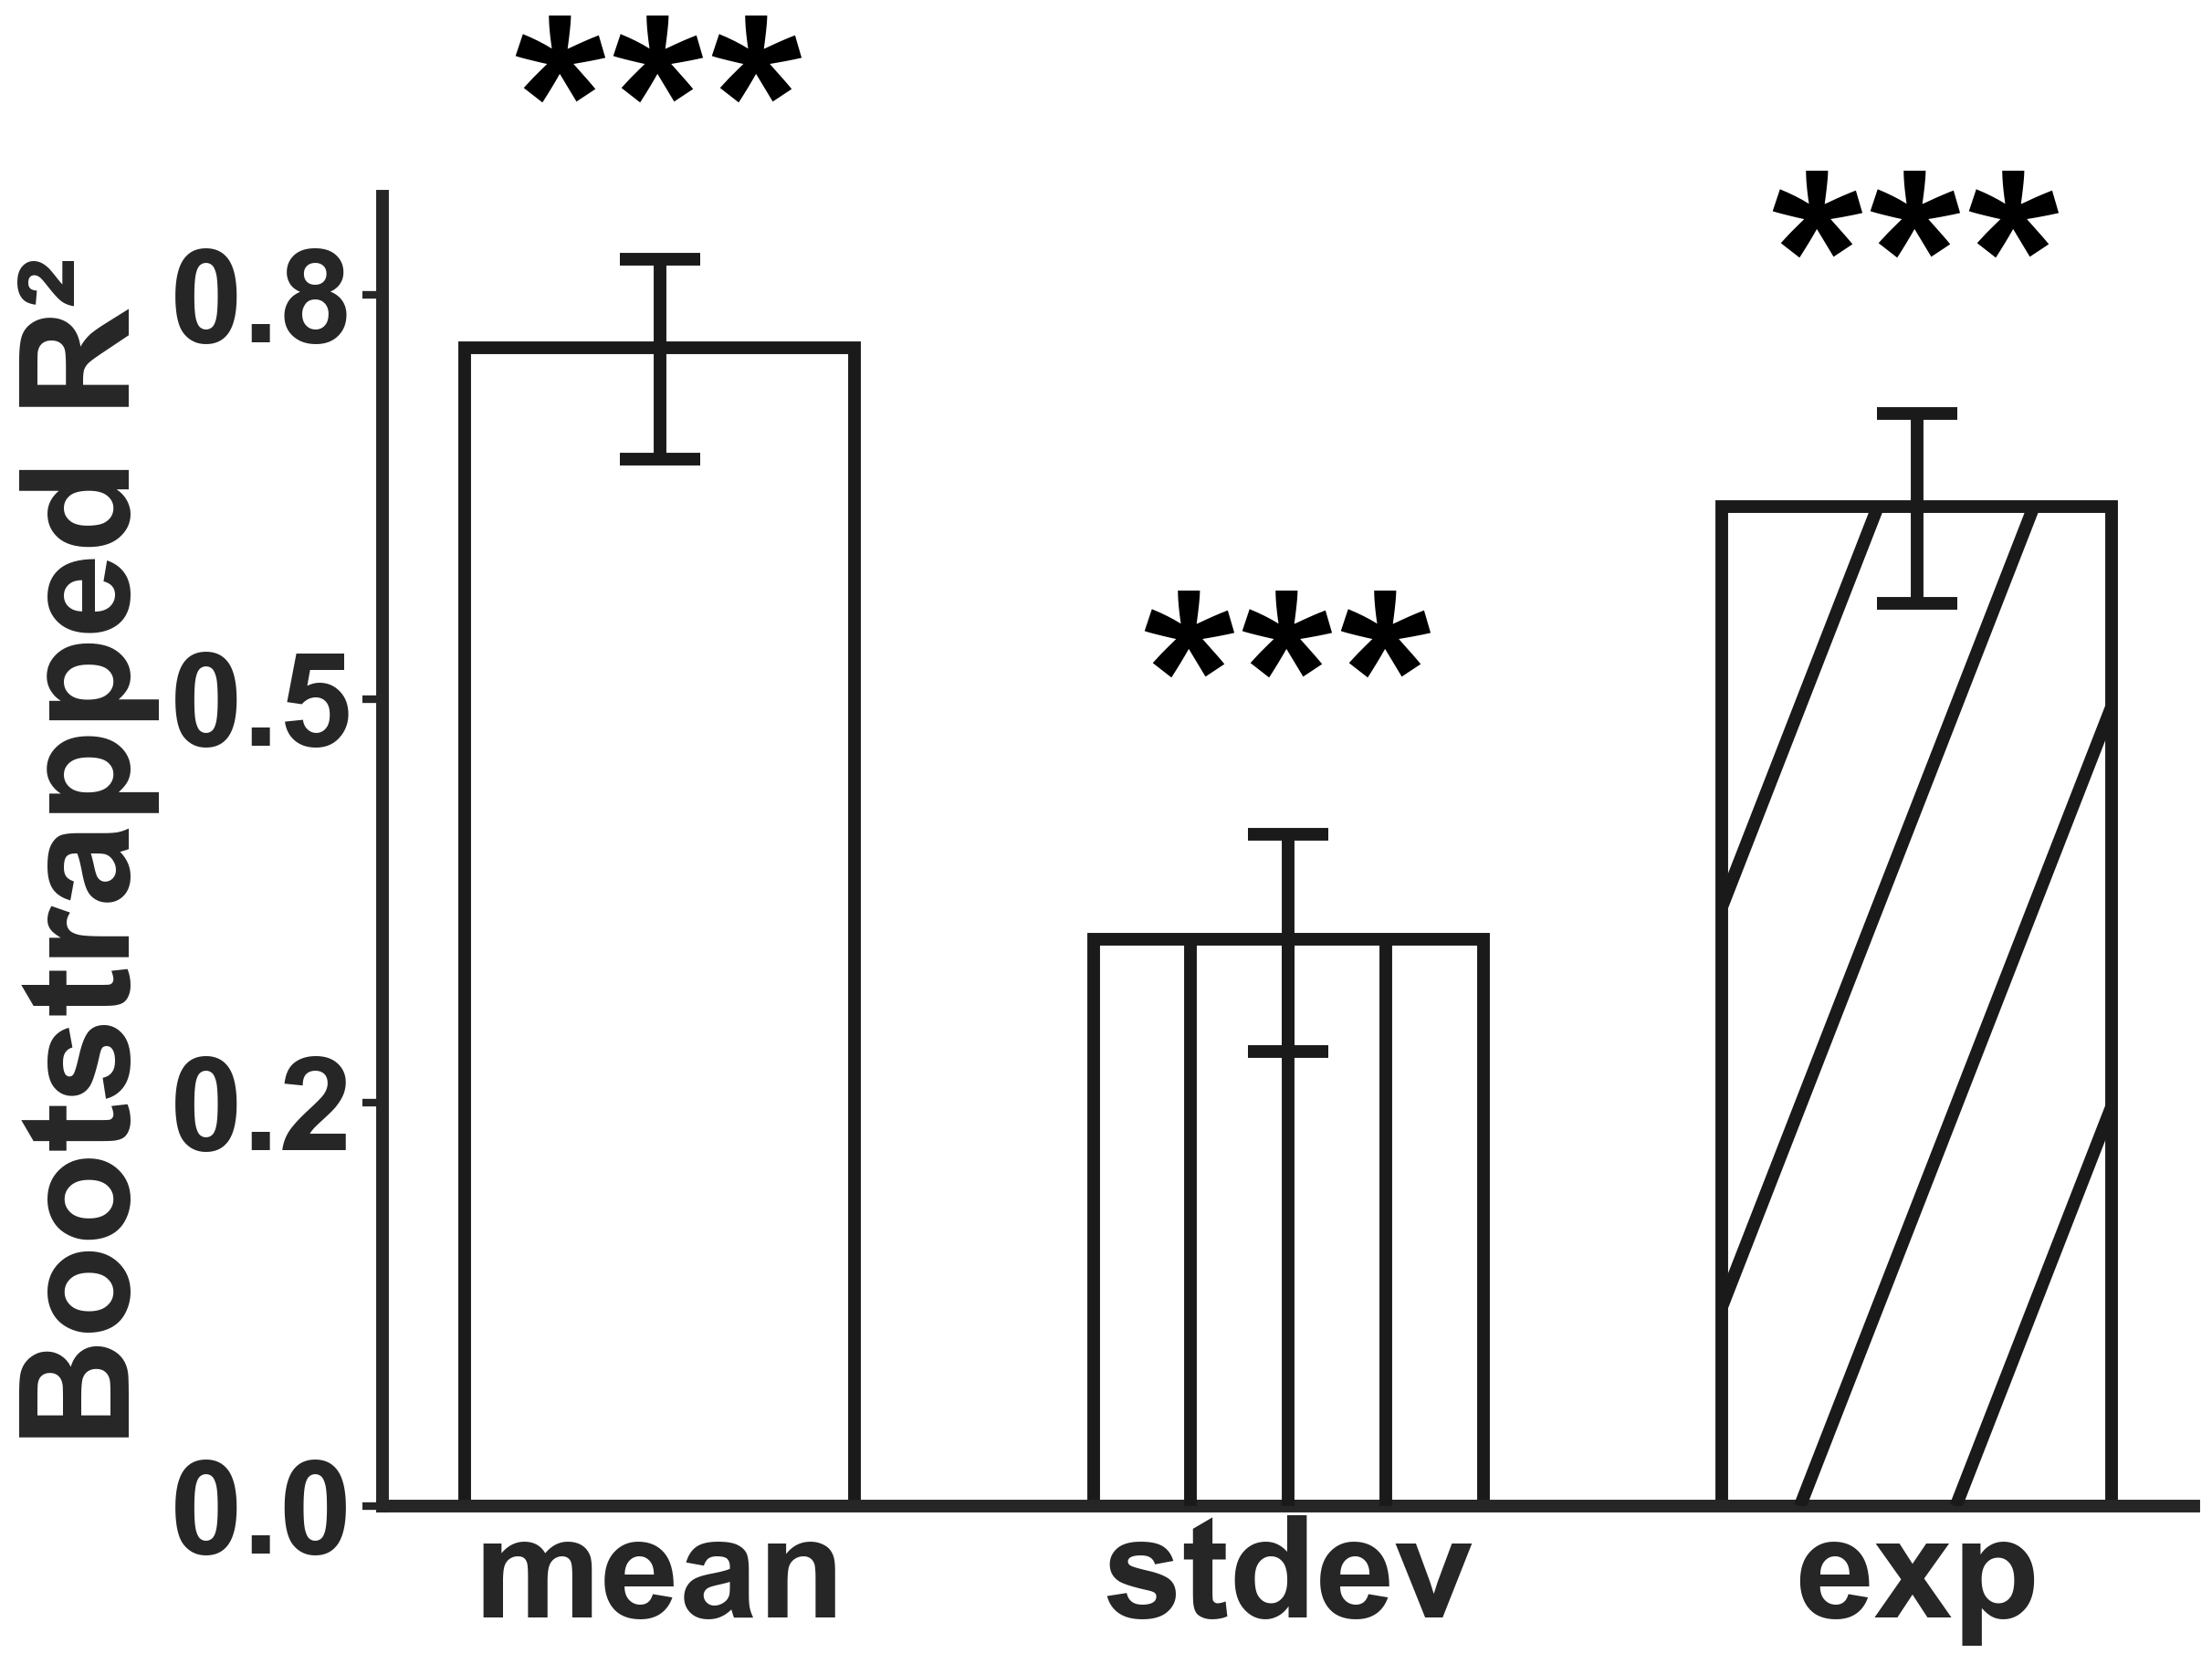

In [10]:
plot_beta_weights_combined(results_win_c1, window_ms=200)

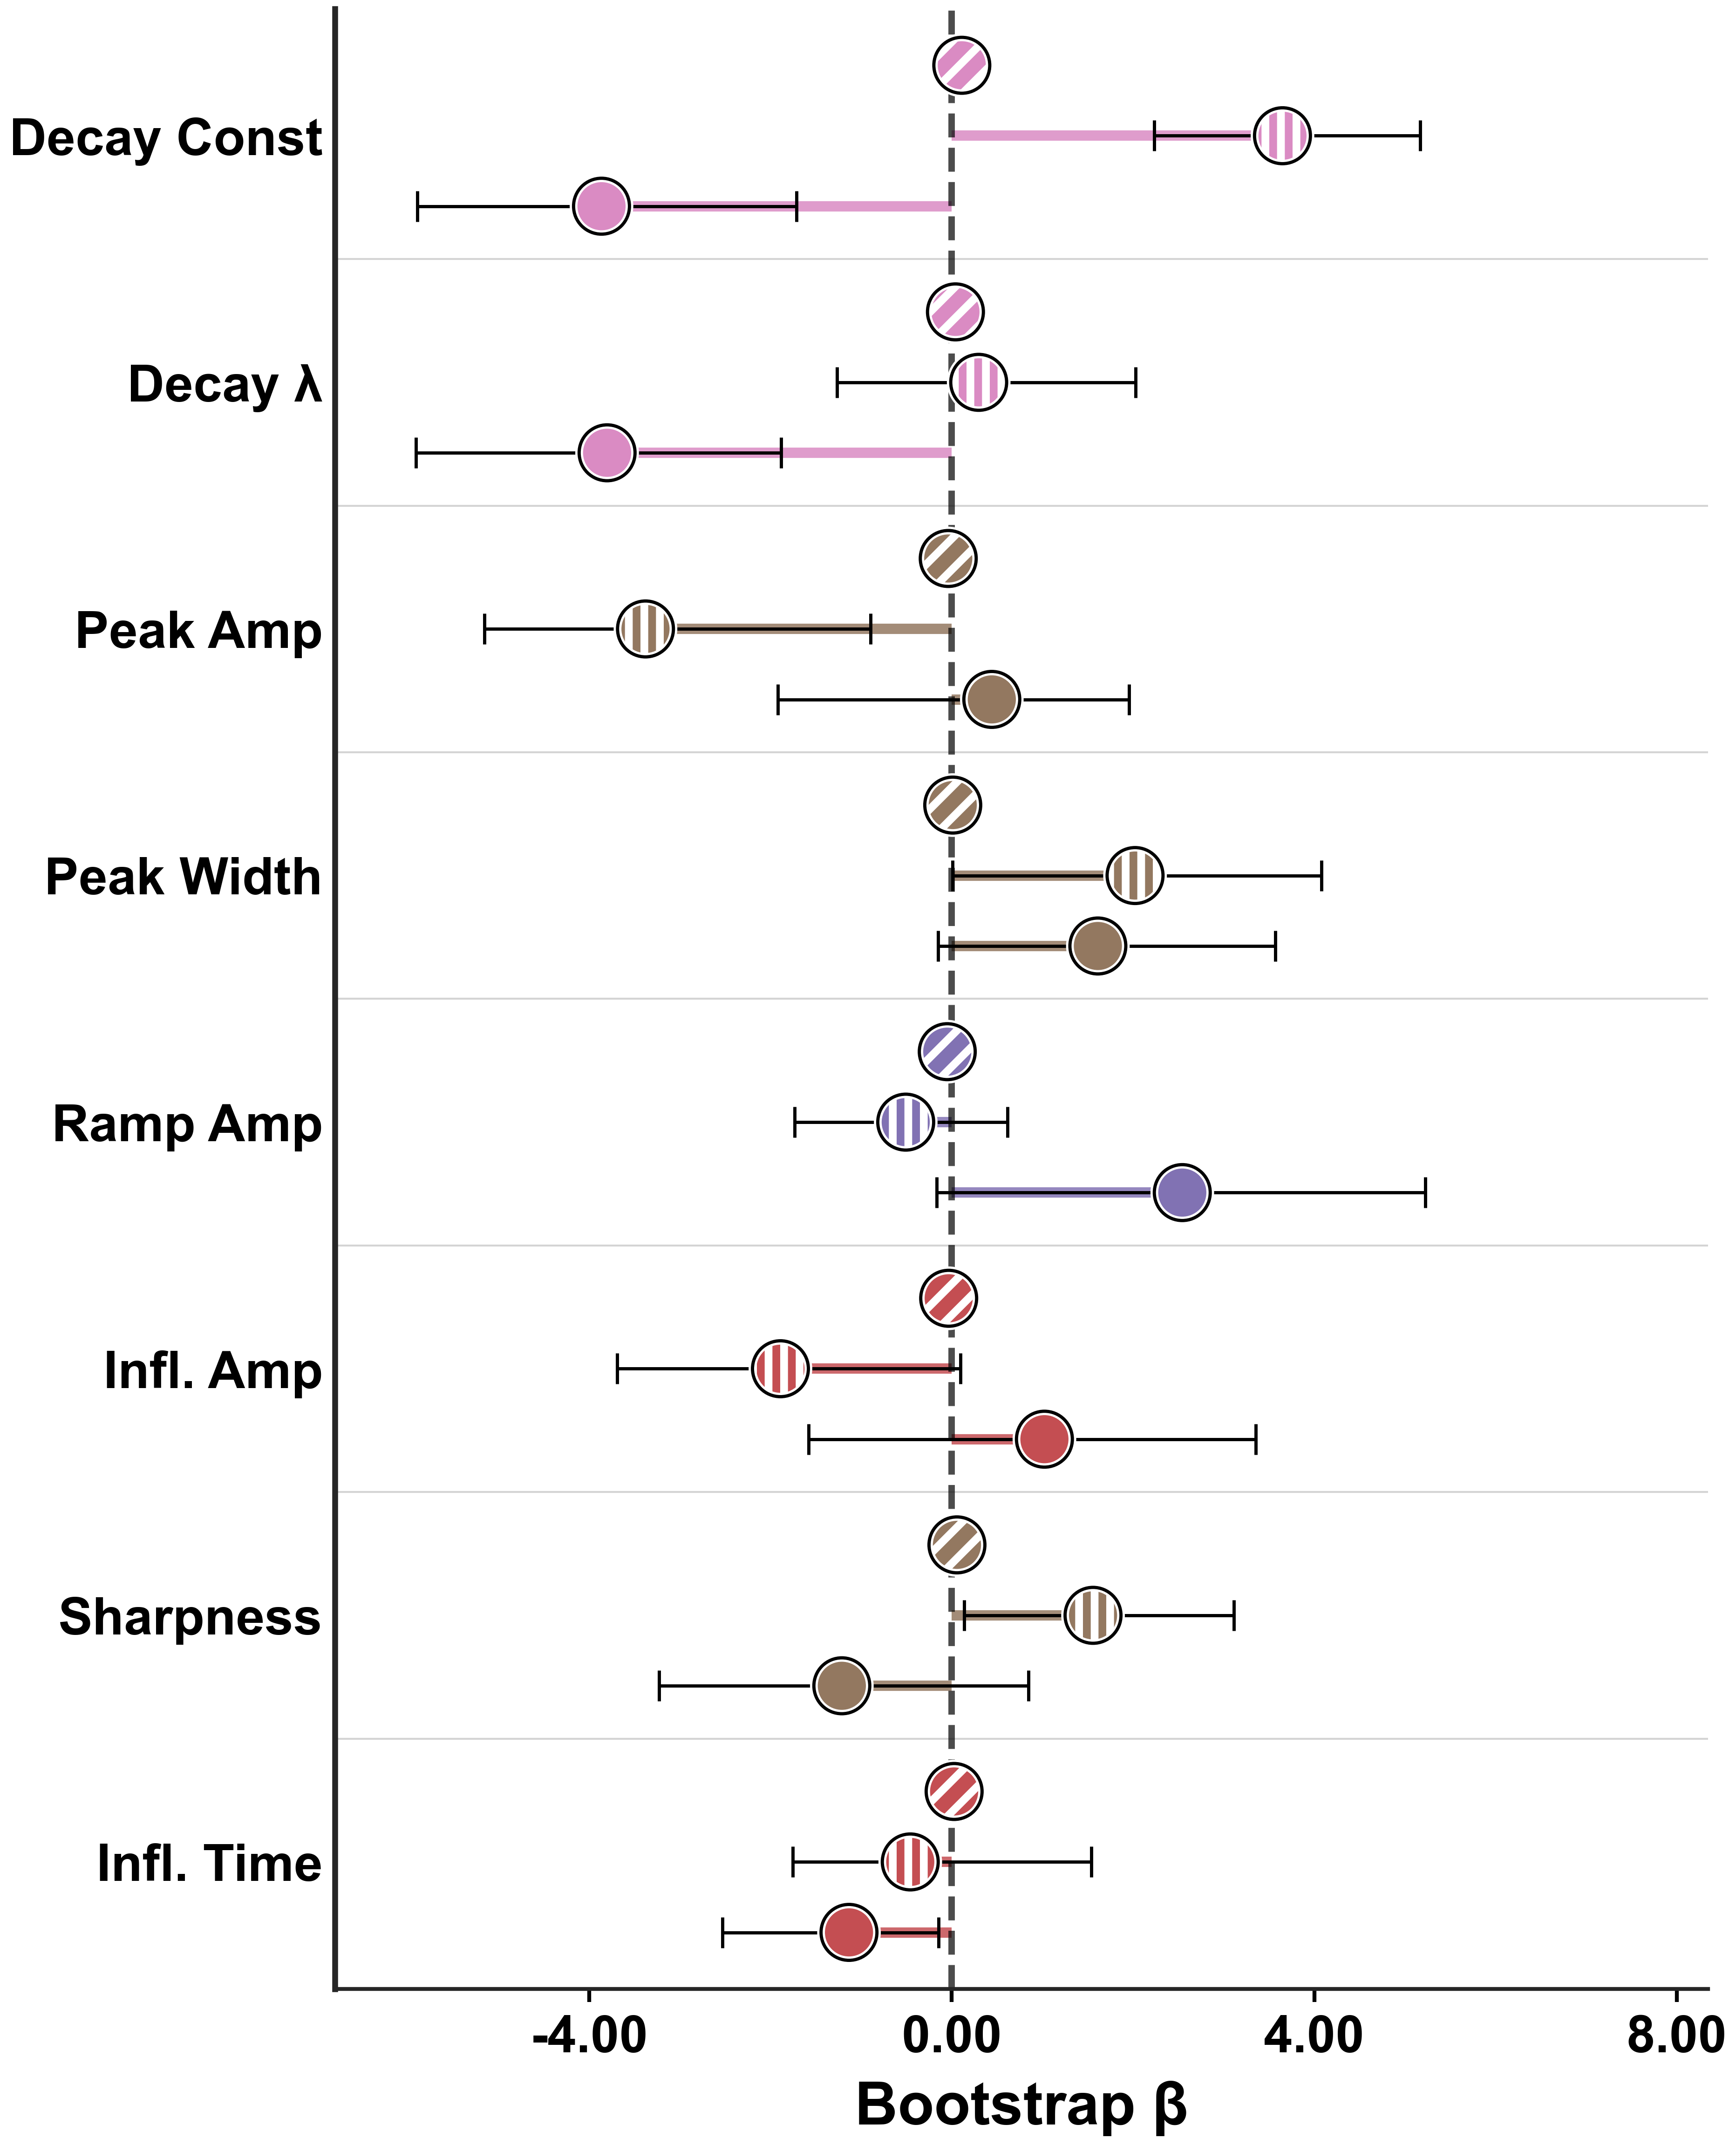

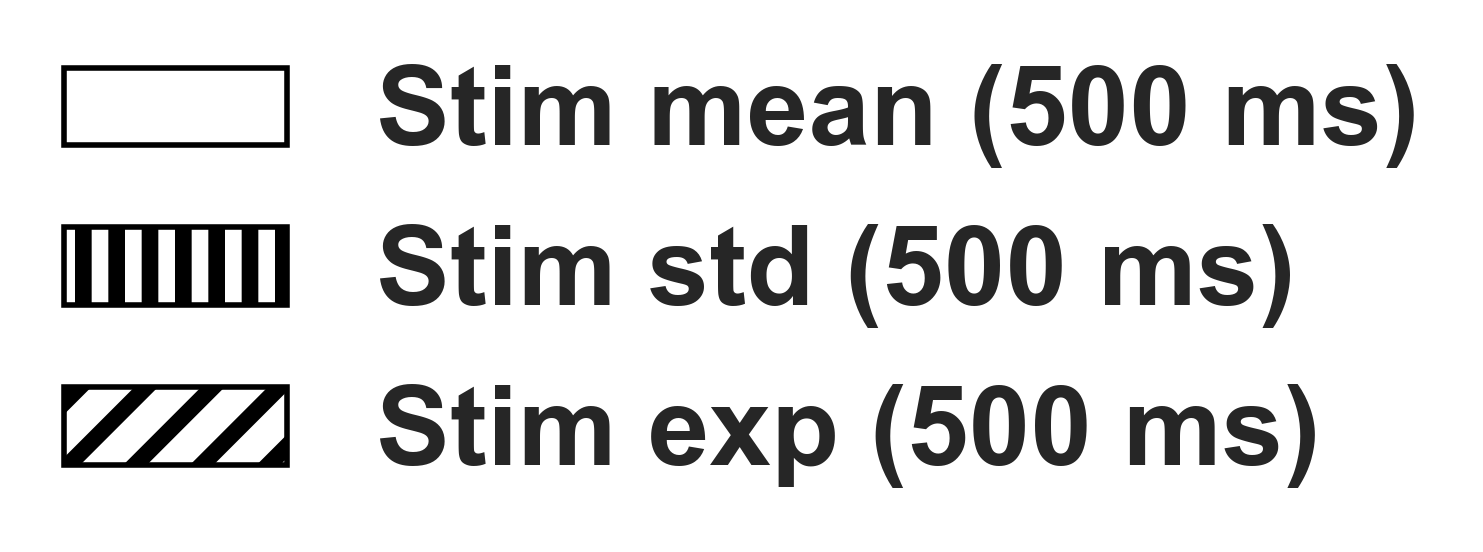

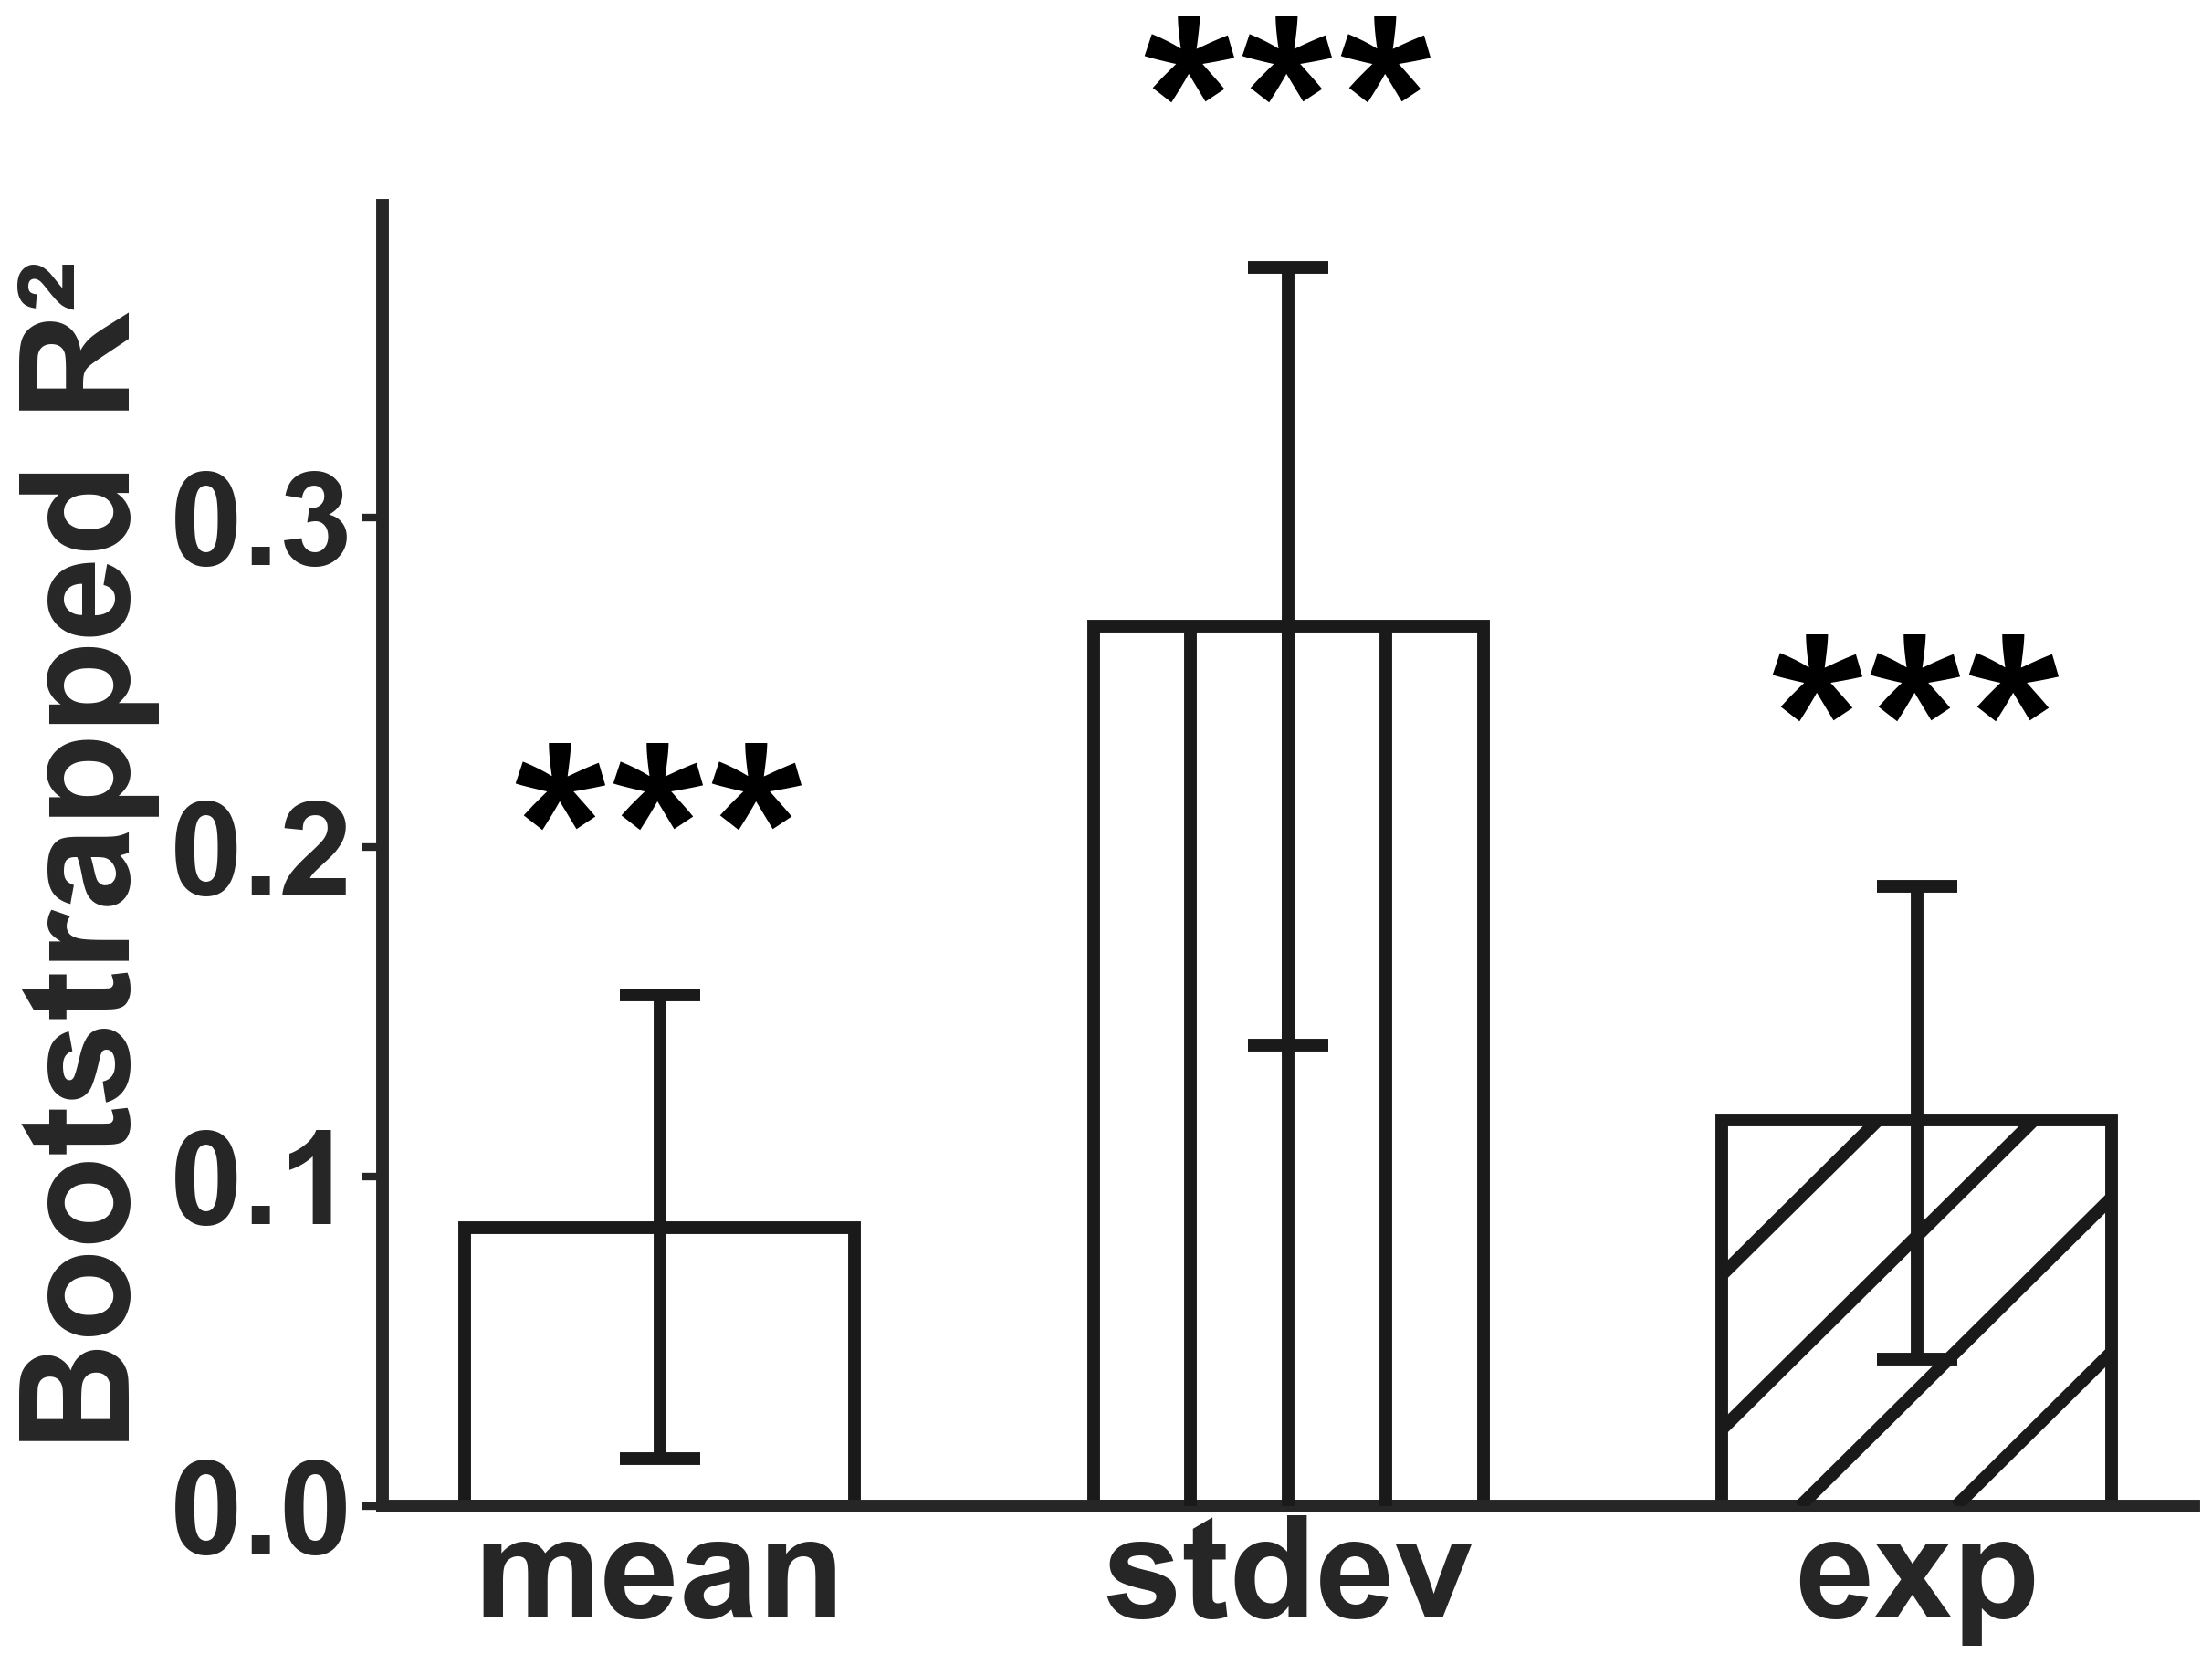

In [11]:
plot_beta_weights_combined(results_win_c2, window_ms=500)

## Fig S5 — Constant/Pink Misclassification Is Driven by Current Amplitude

The stimulation-type classifier (Fig S2) occasionally confuses constant-current spikes with pink-noise spikes. Constant sweeps span a wide range of injected current amplitudes, while pink noise operates in a narrow, low-amplitude range. Sweeps/spikes injected at current levels overlapping pink noise's operating range are misclassified as pink far more often than those at higher current - for both constant (step) and ramp stimuli, using out-of-fold classifier predictions so every spike is included.

In [12]:
cur_results = _load(os.path.join(PICKLE_DIR, 'current_amplitude_misclass_c1.pkl'))
df_const_current = cur_results['df_const_current']
df_ramp_merged   = cur_results['df_ramp_current_merged']
pink_mean_current = cur_results['pink_mean_current']

print(f"Constant sweeps: corr(mean current, % misclassified as pink) = "
      f"{cur_results['const_corr_r']:+.3f}, p={cur_results['const_corr_p']:.5f}, "
      f"n={len(df_const_current)} sweeps")
print(f"Ramp spikes: current <= {cur_results['ramp_pink_range_threshold']} units "
      f"(pink's range) -> {cur_results['ramp_low_current_pct_misclassified']:.1f}% misclassified as pink")
print(f"Ramp spikes: current > {cur_results['ramp_pink_range_threshold']} units "
      f"-> {cur_results['ramp_high_current_pct_misclassified']:.1f}% misclassified as pink")
print(f"Pink noise mean current: {pink_mean_current:.1f} units")

Constant sweeps: corr(mean current, % misclassified as pink) = -0.777, p=0.00006, n=20 sweeps
Ramp spikes: current <= 25 units (pink's range) -> 57.1% misclassified as pink
Ramp spikes: current > 25 units -> 3.9% misclassified as pink
Pink noise mean current: 20.0 units


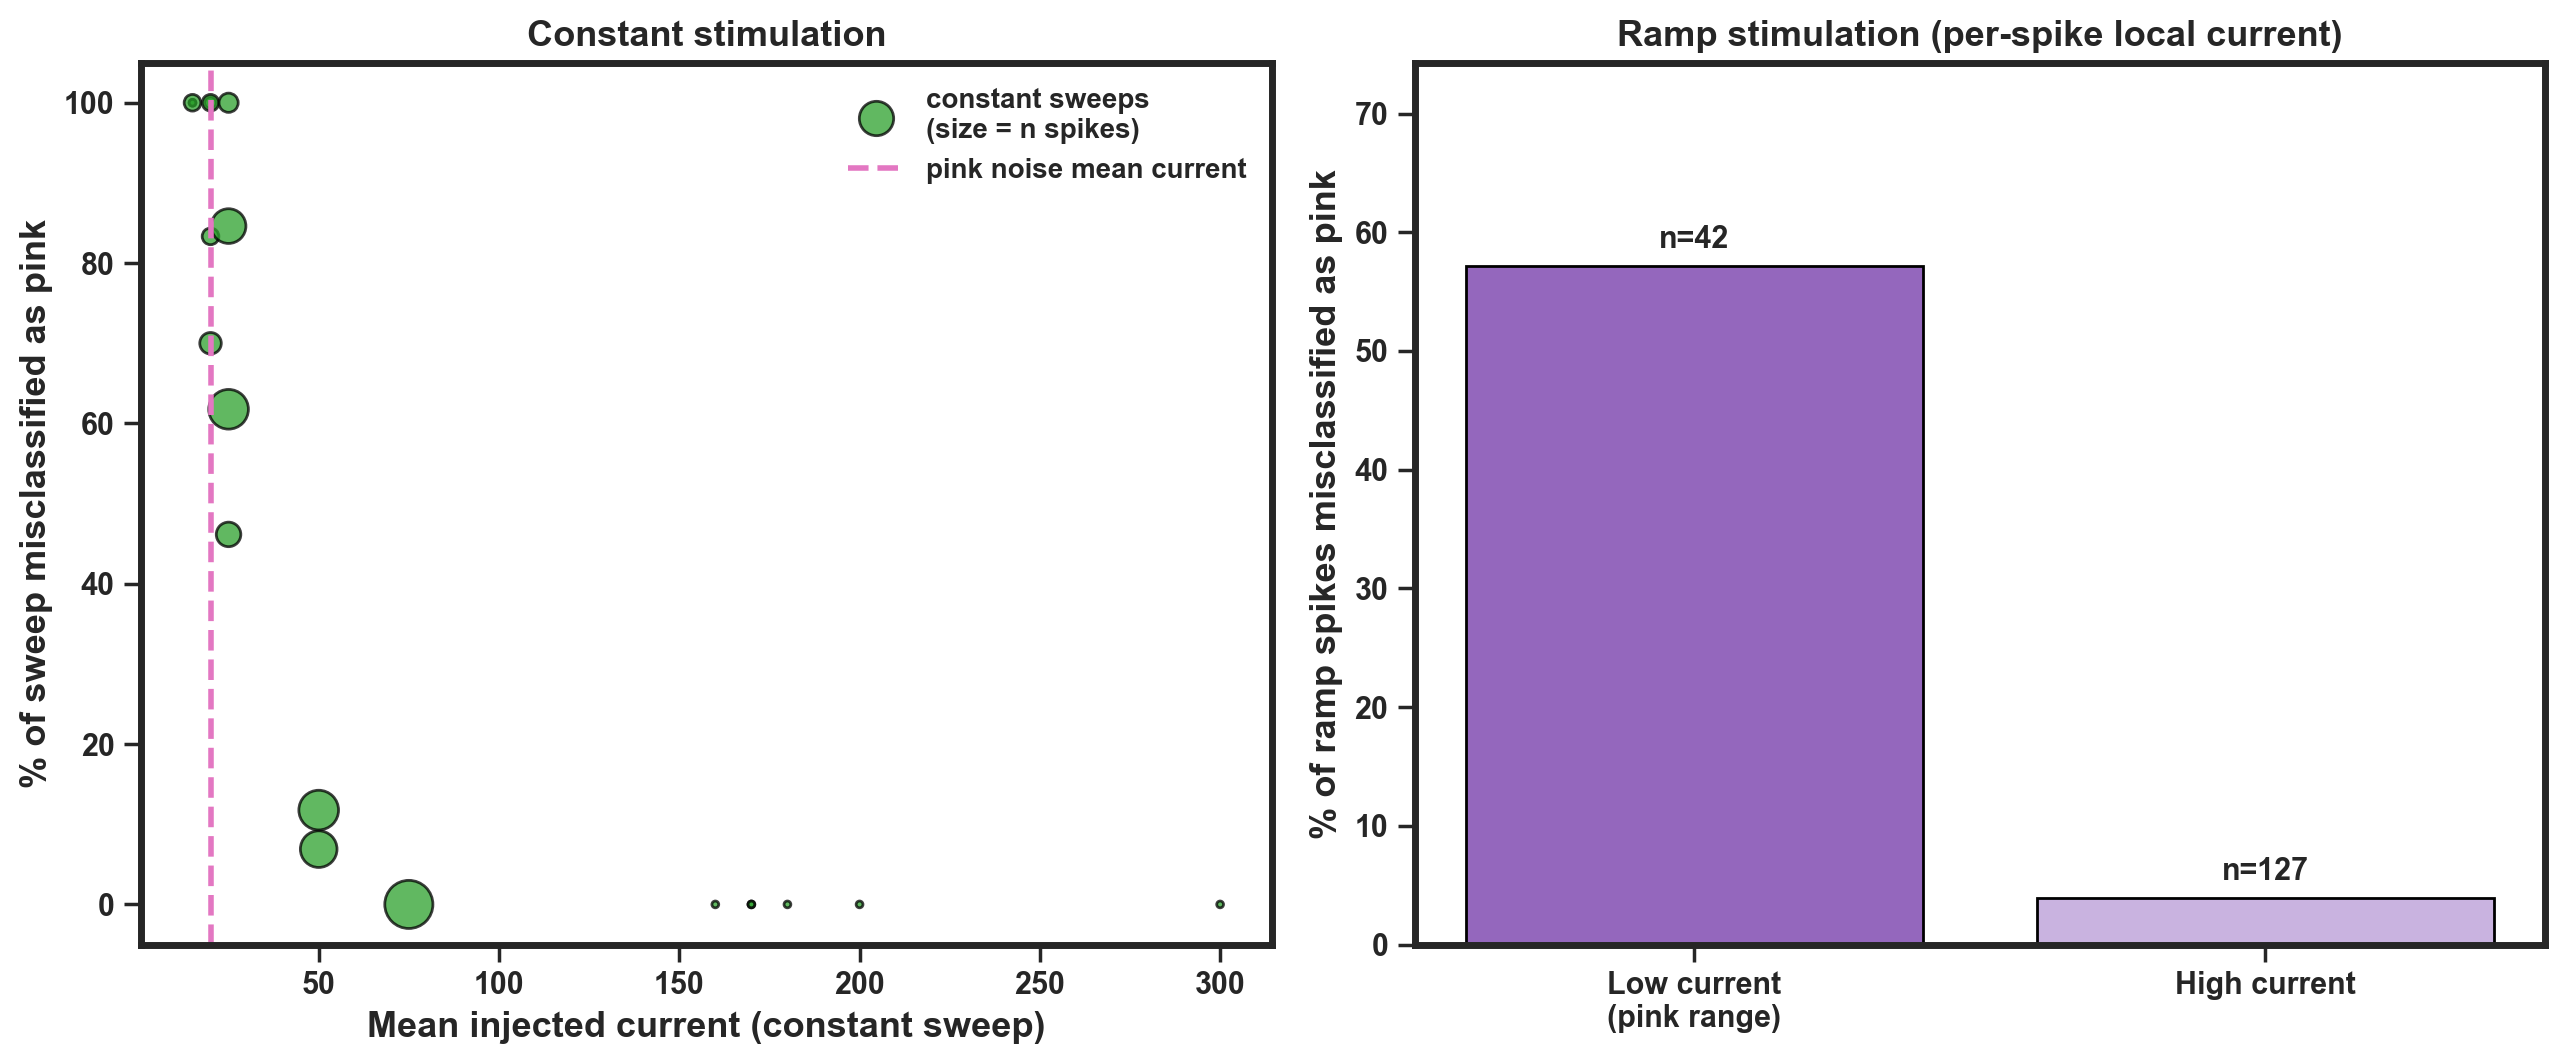

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: constant sweeps, current vs. % misclassified
ax = axes[0]
sc = ax.scatter(df_const_current['mean_current'], df_const_current['pct_misclassified'],
                 s=df_const_current['n_constant'] * 6, alpha=0.75, c='#2ca02c',
                 edgecolor='black', label='constant sweeps\n(size = n spikes)')
ax.axvline(pink_mean_current, color='#e377c2', lw=2, ls='--', label='pink noise mean current')
ax.set_xlabel('Mean injected current (constant sweep)', fontsize=13, fontweight='bold')
ax.set_ylabel('% of sweep misclassified as pink', fontsize=13, fontweight='bold')
ax.set_title('Constant stimulation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, frameon=False)

# Panel 2: ramp spikes, low vs. high local current
ax = axes[1]
low = df_ramp_merged['local_current'] <= cur_results['ramp_pink_range_threshold']
bar_vals = [100 * df_ramp_merged.loc[low, 'misclassified_as_pink'].mean(),
            100 * df_ramp_merged.loc[~low, 'misclassified_as_pink'].mean()]
bar_ns = [low.sum(), (~low).sum()]
bars = ax.bar(['Low current\n(pink range)', 'High current'], bar_vals,
               color=['#9467bd', '#c9b3e0'], edgecolor='black')
for b, n in zip(bars, bar_ns):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f'n={n}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('% of ramp spikes misclassified as pink', fontsize=13, fontweight='bold')
ax.set_title('Ramp stimulation (per-spike local current)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(bar_vals) * 1.3)

plt.tight_layout()
plt.show()

**Summary:** constant sweeps at current levels overlapping pink noise's operating range (~15-25 units, mean 20.0) are misclassified as pink far more often than higher-current constant sweeps (r=-0.78, p<0.0001 across 20 sweeps). The same relationship holds for ramp spikes tested at the level of local current at each spike's occurrence (57.1% vs. 3.9% misclassified, low vs. high current) - indicating the effect is driven by current amplitude at the moment of spike generation, not by stimulus waveform shape (step vs. ramp). This is consistent with the amplitude-dependence of waveform shape established in the pink-noise-only analysis (Fig S3/S4).